In [218]:
"""
06_analysis_crosscompany.py
────────────────────────────
Lädt corpus.parquet, berechnet Frequenzen und erstellt 4 Plots.
Voraussetzung: 05_extraction.py wurde ausgeführt.

Ausführen: python 06_analysis_crosscompany.py
"""

'\n06_analysis_crosscompany.py\n────────────────────────────\nLädt corpus.parquet, berechnet Frequenzen und erstellt 4 Plots.\nVoraussetzung: 05_extraction.py wurde ausgeführt.\n\nAusführen: python 06_analysis_crosscompany.py\n'

In [219]:
import sys
print(sys.executable)
print(sys.version)
import pandas as pd
print(pd.__version__)

/Users/tgumpp/Documents/MasterThesis/venv/bin/python
3.9.12 (main, Apr  5 2022, 01:53:17) 
[Clang 12.0.0 ]
2.3.3


In [220]:
# ════════════════════════════════════════════════════════════════════════════
# KONFIGURATION — hier alle Parameter anpassen
# ════════════════════════════════════════════════════════════════════════════
import re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore')

In [221]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 150,
    'figure.facecolor': 'white',
})

In [222]:
# ── Pfade ──
PROJECT_ROOT = Path('/Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis')
CORPUS_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'corpus.parquet'
FIG_DIR      = PROJECT_ROOT / 'outputs' / 'figures' / 'cross_company'
REP_DIR      = PROJECT_ROOT / 'outputs' / 'reports'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REP_DIR.mkdir(parents=True, exist_ok=True)

In [223]:
# ── Analysejahre ──
YEARS = [2022, 2023, 2024, 2025]

In [224]:
# ── Schlagwortgruppen (Groß-/Kleinschreibung wird ignoriert) ──
TERMS = {
    'KI/AI': [
        'ki', 'ai',
        'artificial intelligence',
        'machine learning', 'deep learning', 'maschinelles Lernen', 'maschinellem Lernen',
        'large language model', 'llm', 'GenAI',
        '~künstlich\\w*\\s+intelligenz',
    ],
    'Daten/Data': [
        'daten', 'data',
        'datengetrieben', 'datenarchitektur', 'datenstrategie',
        'datenverfügbarkeit', 'datenqualität',
        'datenplattform', 'datensilo', 'datensilos', 'datenhoheit', 'datenzugang', 'datenbasiert'
    ],
}
GROUPS = list(TERMS.keys())

In [225]:
# ── Farben ──
C = {
    'KI/AI':      '#1A5F9E',
    'Daten/Data': '#D95F2B',
    'ceo':        '#1A5F9E',
    'ar':         '#D95F2B',
}

In [226]:
NORM_FACTOR = 1000

In [227]:
print('✓ Konfiguration geladen')
print(f'  KI/AI-Terme     : {TERMS["KI/AI"]}')
print(f'  Daten/Data-Terme: {TERMS["Daten/Data"]}')

✓ Konfiguration geladen
  KI/AI-Terme     : ['ki', 'ai', 'artificial intelligence', 'machine learning', 'deep learning', 'maschinelles Lernen', 'maschinellem Lernen', 'large language model', 'llm', 'GenAI', '~künstlich\\w*\\s+intelligenz']
  Daten/Data-Terme: ['daten', 'data', 'datengetrieben', 'datenarchitektur', 'datenstrategie', 'datenverfügbarkeit', 'datenqualität', 'datenplattform', 'datensilo', 'datensilos', 'datenhoheit', 'datenzugang', 'datenbasiert']


In [228]:
def count_term(text: str, term: str) -> int:
    """
    Zählt Vorkommen eines Terms im Text.
    Terme die mit '~' beginnen werden als Regex behandelt.
    Alle anderen werden als exakte Wortgrenz-Suche behandelt.
    """
    if not text:
        return 0

    if term.startswith('~'):
        # Regex-Modus: '~' entfernen, direkt als Pattern verwenden
        pattern = term[1:]
        return len(re.findall(pattern, text, re.IGNORECASE))
    else:
        # Exakter Modus: Wortgrenzen + escape (bisheriges Verhalten)
        pattern = r'\b' + re.escape(term) + r'\b'
        return len(re.findall(pattern, text, re.IGNORECASE))

In [229]:
corpus = pd.read_parquet(CORPUS_PATH)
corpus = corpus[corpus['year'].isin(YEARS)].copy()
print(f'\nCorpus: {len(corpus)} Dokumente | {corpus["company"].nunique()} Firmen')


Corpus: 240 Dokumente | 36 Firmen


In [230]:
# Sanity-Check: Regex-Terme testen
test_doc = corpus[corpus['company'] == 'SAP'].iloc[-1]  # neuestes Siemens-Dok
for term in TERMS['KI/AI'] + TERMS['Daten/Data']:
    n = count_term(test_doc['text'], term)
    if n > 0:
        print(f"  {n:3}x  {term}")

    1x  ki
    1x  ai
    1x  ~künstlich\w*\s+intelligenz
    2x  daten
    1x  data


In [231]:
rows = []
for _, doc in corpus.iterrows():
    for group, terms in TERMS.items():
        raw  = sum(count_term(doc['text'], t) for t in terms)
        norm = (raw / doc['wordcount']) * NORM_FACTOR if doc['wordcount'] > 0 else 0
        rows.append({
            'company':    doc['company'],
            'sector':     doc['sector'],
            'year':       doc['year'],
            'role':       doc['role'],
            'language':   doc['language'],
            'wordcount':  doc['wordcount'],
            'group':      group,
            'count_raw':  raw,
            'count_norm': round(norm, 4),
        })

In [232]:
freq = pd.DataFrame(rows)

In [233]:
agg = freq.groupby(['company', 'sector', 'year', 'group']).agg(
    count_raw=('count_raw', 'sum'),
    count_norm=('count_norm', 'mean'),
    wordcount=('wordcount', 'sum'),
).reset_index()

In [234]:
freq.to_csv(REP_DIR / 'freq_detail.csv',     index=False, encoding='utf-8-sig')
agg.to_csv(REP_DIR  / 'freq_aggregated.csv', index=False, encoding='utf-8-sig')
print('✓ freq_detail.csv & freq_aggregated.csv exportiert')

✓ freq_detail.csv & freq_aggregated.csv exportiert


In [235]:
# ── SEED EXPANSION: Welche Wörter stehen nah bei KI-Termen? ──────────────────
from collections import Counter
import re

WINDOW = 5  # Wörter links und rechts

# Bekannte Seed-Terme (deine aktuellen KI-Terme)
SEEDS = [
    'ki', 'ai', 'künstlich', 'intelligenz',
    'machine learning', 'deep learning',
]

STOPWORDS = {
    'der','die','das','und','in','zu','den','des','von','mit','auf','für',
    'ist','im','an','als','auch','sich','es','ein','eine','einer','einem',
    'wir','sie','nicht','dass','aus','bei','durch','nach','bis','über',
    'sind','haben','wird','werden','wurde','wurden','hat','hatte','kann',
    'um','so','wie','aber','oder','wenn','uns','ihm','ihr','ihn','ihre',
    'dem','war','eines','unserem','unsere','dabei','bereits','sowie',
    'noch','mehr','können','this','that','the','and','our','with','for',
    'have','been','will','also','which','their','from','these','those',
    'its','not','are','has','was','were','but','they','we','by','an',
    'as','at','be','do','if','it','of','on','or','to','us',
}

neighbor_counter = Counter()

for _, doc in corpus[corpus['year'].isin(YEARS)].iterrows():
    words = doc['text'].lower().split()
    words_clean = [re.sub(r'[^a-zäöüß\-]', '', w) for w in words]

    for i, word in enumerate(words_clean):
        # Prüfen ob dieses Wort ein Seed-Treffer ist
        is_seed = any(
            re.search(r'\b' + re.escape(seed) + r'\b', word)
            for seed in SEEDS
        )
        if not is_seed:
            continue

        # Nachbarn im Fenster sammeln
        start = max(0, i - WINDOW)
        end   = min(len(words_clean), i + WINDOW + 1)
        for neighbor in words_clean[start:end]:
            if (neighbor and neighbor != word
                    and neighbor not in STOPWORDS
                    and len(neighbor) > 3):
                neighbor_counter[neighbor] += 1

In [236]:
# Top-Nachbarn ausgeben
print(f'Top-50 Nachbarwörter um KI-Terme (±{WINDOW} Wörter):\n')
for word, count in neighbor_counter.most_common(100):
    print(f'  {count:4}x  {word}')

Top-50 Nachbarwörter um KI-Terme (±5 Wörter):

   135x  künstliche
    84x  künstlicher
    25x  einsatz
    22x  digitalisierung
    21x  intelligenz
    20x  daten
    19x  nutzen
    16x  beispiel
    15x  einen
    15x  kunden
    15x  business
    14x  technologien
    13x  künstlichen
    13x  kurz
    12x  hilft
    12x  themen
    12x  bereich
    11x  diese
    11x  data
    11x  unternehmen
    11x  entwickelt
    11x  unseren
    11x  digitale
    10x  setzen
    10x  damit
    10x  siemens
     9x  anwendung
     9x  unserer
     9x  hilfe
     9x  lösungen
     9x  immer
     9x  zukunft
     9x  software
     9x  geschäftsanwendungen
     8x  schneller
     8x  mithilfe
     8x  viel
     8x  machen
     8x  unser
     7x  thema
     7x  basis
     7x  weiter
     7x  unter
     7x  verbessern
     7x  neue
     7x  kommt
     7x  ermöglichen
     7x  heute
     7x  celestial
     7x  schon
     6x  besser
     6x  betrieb
     6x  dieses
     6x  seite
     6x  viele
   

In [237]:
# ════════════════════════════════════════════════════════════════════════════
# STUPIDITY CHECK 2: KWIC für Daten/Data
# ════════════════════════════════════════════════════════════════════════════
def kwic_check(corpus, terms, company=None, year=None, window_sentences=1):
    """
    Gibt alle Vorkommen der Terms im Satzkontext aus.
    window_sentences=1 → den ganzen Satz in dem der Treffer liegt.
    """
    subset = corpus.copy()
    if company:
        subset = subset[subset['company'] == company]
    if year:
        subset = subset[subset['year'] == year]

    results = []
    for _, doc in subset.iterrows():
        # Text in Sätze aufteilen
        sentences = re.split(r'(?<=[.!?])\s+', doc['text'])
        for sent in sentences:
            for term in terms:
                pattern = r'\b' + re.escape(term) + r'\b'
                if re.search(pattern, sent, re.IGNORECASE):
                    # Treffer im Satz markieren
                    marked = re.sub(
                        pattern,
                        lambda m: f'>>>{m.group()}<<<',
                        sent,
                        flags=re.IGNORECASE
                    )
                    results.append({
                        'company': doc['company'],
                        'year':    doc['year'],
                        'role':    doc['role'],
                        'term':    term,
                        'context': marked.strip(),
                    })

    df = pd.DataFrame(results)
    return df

In [238]:
# Ausführen — alle Daten/Data-Treffer ausgeben
daten_kwic = kwic_check(
    corpus,
    terms=TERMS['Daten/Data'],
    # company='SAP',   # optional: auf eine Firma einschränken
    # year=2024,       # optional: auf ein Jahr einschränken
)

In [239]:
print(f'\nDaten/Data-Treffer gesamt: {len(daten_kwic)}')
print(f'Davon verdächtig kurze Kontexte (< 20 Zeichen):')
short = daten_kwic[daten_kwic['context'].str.len() < 40]
print(short[['company','year','role','context']].to_string(index=False))


Daten/Data-Treffer gesamt: 206
Davon verdächtig kurze Kontexte (< 20 Zeichen):
       company  year role                                 context
       Allianz  2024  ceo     Teilweise fehlen\n>>>Daten<<< ganz.
           BMW  2024  ceo    Mittels KI und >>>Data<<< Analytics.
           BMW  2024  ceo       >>>Datenbasiert<<< über Catena-X.
      Brenntag  2025   ar          >>>Data<<<.Excellence (DiDEX).
   Continental  2023  ceo           Und >>>Daten<<< zu entwenden.
DeutscheBoerse  2022  ceo         Märkte produzieren >>>Daten<<<.
DeutscheBoerse  2022  ceo             >>>Daten<<< bewegen Märkte.
DeutscheBoerse  2022  ceo    Die >>>Daten<<< sprechen da für uns.
           Eon  2023  ceo               Die >>>Daten<<< sicherer.
     Fresenius  2024  ceo                            >>>Daten<<<.
     Fresenius  2024  ceo            Sie basiert auf >>>Daten<<<.
    HannoverRe  2022  ceo                   Und ihre >>>Daten<<<.
           SAP  2024  ceo  Und wir harmonisieren die >>>Daten<

In [240]:
# Export zur manuellen Durchsicht
daten_kwic.to_csv(
    REP_DIR / 'kwic_daten_check.csv',
    index=False,
    encoding='utf-8-sig'
)
print(f'\n✓ Alle Treffer exportiert nach: {REP_DIR}/kwic_daten_check.csv')


✓ Alle Treffer exportiert nach: /Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis/outputs/reports/kwic_daten_check.csv


## Plot 1 — Zeitverlauf: y1 = norm, y2 = Gesamtsumme

## Plot 1 (CEO only)

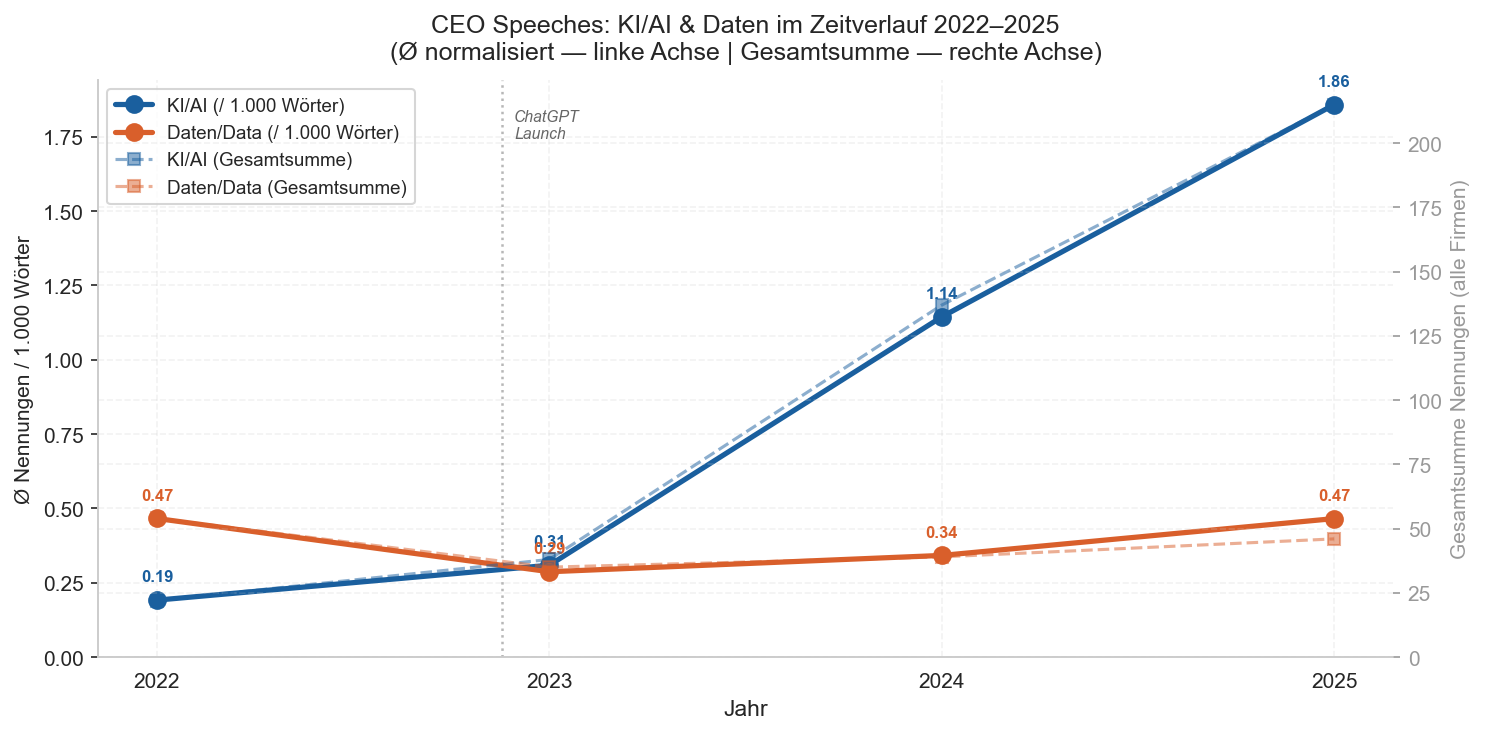

In [241]:
# ── PLOT 1 CEO ONLY: Zeitverlauf y1=norm, y2=Summe ───────────────────────────

yearly_ceo = freq[freq['role'] == 'ceo'].groupby(['year', 'group']).agg(
    norm_mean=('count_norm', 'mean'),
    raw_sum=('count_raw',   'sum'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

for group in GROUPS:
    sub   = yearly_ceo[yearly_ceo['group'] == group].sort_values('year')
    color = C[group]
    ax1.plot(sub['year'], sub['norm_mean'], marker='o', linewidth=2.5,
             markersize=8, color=color, label=f'{group} (/ 1.000 Wörter)', zorder=3)
    ax2.plot(sub['year'], sub['raw_sum'], marker='s', linewidth=1.5,
             markersize=6, color=color, linestyle='--', alpha=0.5,
             label=f'{group} (Gesamtsumme)', zorder=2)
    for _, row in sub.iterrows():
        ax1.annotate(f"{row['norm_mean']:.2f}",
                     (row['year'], row['norm_mean']),
                     xytext=(0, 9), textcoords='offset points',
                     ha='center', fontsize=8, color=color, fontweight='bold')

ax1.axvline(x=2022.88, color='#999', linestyle=':', linewidth=1.2, alpha=0.7)
ax1.text(2022.91, ax1.get_ylim()[1] * 0.95,
         'ChatGPT\nLaunch', fontsize=7.5, color='#666', style='italic', va='top')

ax1.set_xticks(YEARS)
ax1.set_xlabel('Jahr', fontsize=11)
ax1.set_ylabel('Ø Nennungen / 1.000 Wörter', fontsize=10)
ax2.set_ylabel('Gesamtsumme Nennungen (alle Firmen)', fontsize=10, color='#999')
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis='y', colors='#999')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x)}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title('CEO Speeches: KI/AI & Daten im Zeitverlauf 2022–2025\n'
              '(Ø normalisiert — linke Achse | Gesamtsumme — rechte Achse)',
              fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot1_zeitverlauf_ceo_only.png', bbox_inches='tight')
plt.show()

# Plot 2 — KI vs. Daten: gestapelte Balken (absolut + prozentual)

In [242]:
print('\nAufteilung KI vs. Daten:')
print(pivot_raw[GROUPS + [f'{g}_pct' for g in GROUPS]].round(1).to_string())


Aufteilung KI vs. Daten:
group  KI/AI  Daten/Data  KI/AI_pct  Daten/Data_pct
year                                               
2022    39.0        64.0       37.9            62.1
2023    66.0        45.0       59.5            40.5
2024   228.0        45.0       83.5            16.5
2025   345.0        52.0       86.9            13.1


## Plot 2 CEO only


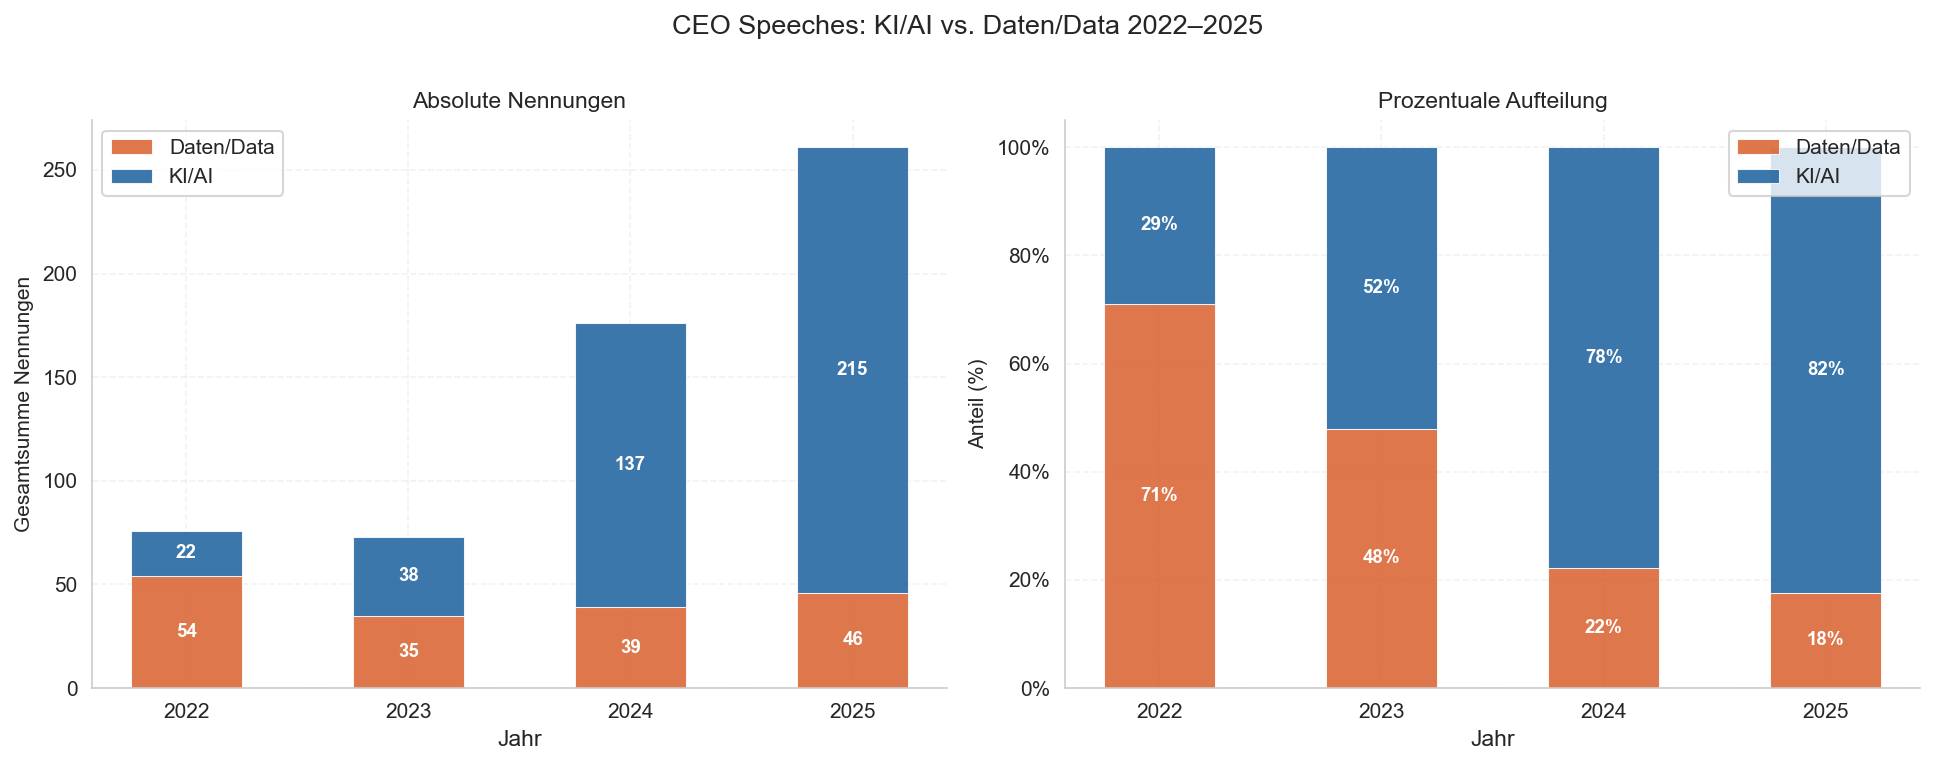

In [243]:
# ── PLOT 2 CEO ONLY: KI vs. Daten gestapelt ──────────────────────────────────

yearly_ceo_raw = freq[freq['role'] == 'ceo'].groupby(['year', 'group']).agg(
    raw_sum=('count_raw', 'sum'),
).reset_index()

pivot_ceo = yearly_ceo_raw.pivot_table(
    index='year', columns='group', values='raw_sum', fill_value=0
)
pivot_ceo['total'] = pivot_ceo.sum(axis=1)
for g in GROUPS:
    pivot_ceo[f'{g}_pct'] = pivot_ceo[g] / pivot_ceo['total'] * 100

fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CEO Speeches: KI/AI vs. Daten/Data 2022–2025', fontsize=13, y=1.01)

x = np.arange(len(YEARS))
bar_w = 0.5

for ax, value_col, ylabel, title, fmt in [
    (ax_abs, 'raw',  'Gesamtsumme Nennungen', 'Absolute Nennungen',     '{:.0f}'),
    (ax_pct, 'pct',  'Anteil (%)',             'Prozentuale Aufteilung', '{:.0f}%'),
]:
    bottom = np.zeros(len(YEARS))
    for group in ['Daten/Data', 'KI/AI']:
        col  = group if value_col == 'raw' else f'{group}_pct'
        vals = [pivot_ceo.loc[y, col] for y in YEARS]
        bars = ax.bar(x, vals, bar_w, bottom=bottom,
                      label=group, color=C[group], alpha=0.85,
                      edgecolor='white', linewidth=0.5)
        for rect, v, b in zip(bars, vals, bottom):
            if v > (3 if value_col == 'pct' else 1):
                ax.text(rect.get_x() + rect.get_width() / 2,
                        b + v / 2, fmt.format(v),
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
        bottom += np.array(vals)

    ax.set_xticks(x)
    ax.set_xticklabels(YEARS)
    ax.set_xlabel('Jahr', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    if value_col == 'pct':
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot2_ki_vs_daten_ceo_only.png', bbox_inches='tight')
plt.show()

## PLOT 3 — Anteil Firmen mit mind. 1 Nennung, CEO vs. AR

  ✓ plot3_penetration_ceo_vs_ar.png


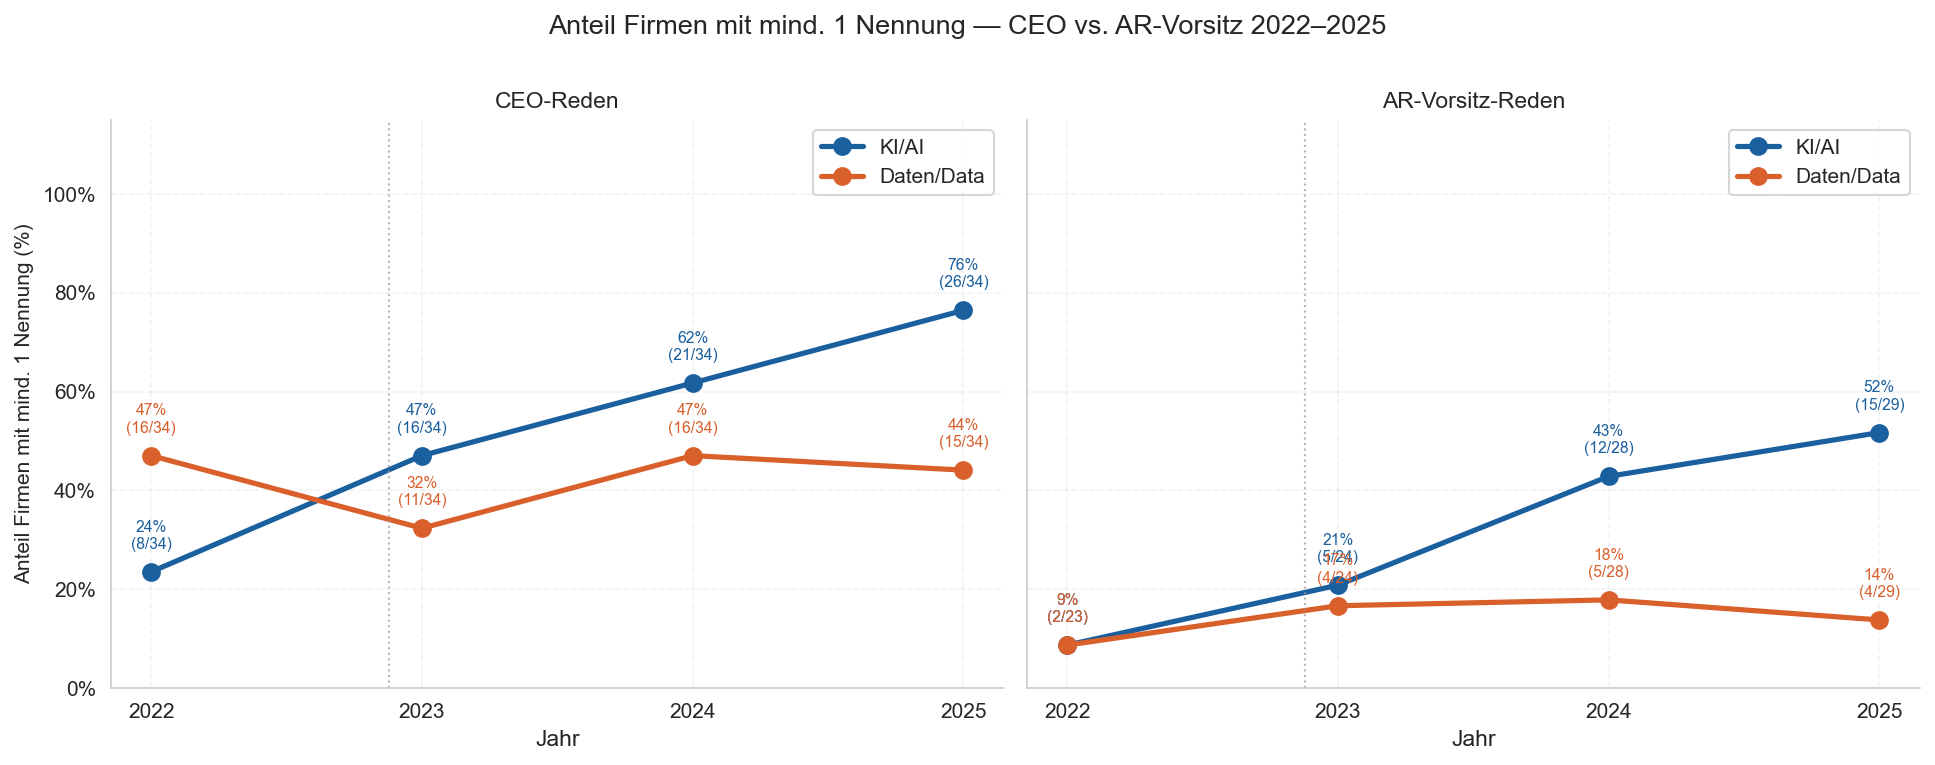

In [244]:
pen_rows = []
for year in YEARS:
    for group in GROUPS:
        for role in ['ceo', 'ar']:
            sub = freq[
                (freq['year'] == year) &
                (freq['group'] == group) &
                (freq['role'] == role)
            ]
            if sub.empty:
                continue
            total    = sub['company'].nunique()
            with_hit = sub[sub['count_raw'] > 0]['company'].nunique()
            pen_rows.append({
                'year':        year,
                'group':       group,
                'role':        role,
                'total_cos':   total,
                'cos_with_hit': with_hit,
                'pct':         with_hit / total * 100 if total > 0 else 0,
            })

pen = pd.DataFrame(pen_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(
    'Anteil Firmen mit mind. 1 Nennung — CEO vs. AR-Vorsitz 2022–2025',
    fontsize=13, y=1.01
)

role_labels = {'ceo': 'CEO-Reden', 'ar': 'AR-Vorsitz-Reden'}

for ax, role in zip(axes, ['ceo', 'ar']):
    for group in GROUPS:
        sub = pen[(pen['role'] == role) & (pen['group'] == group)].sort_values('year')
        ax.plot(sub['year'], sub['pct'], marker='o', linewidth=2.5,
                markersize=8, color=C[group], label=group)
        for _, row in sub.iterrows():
            ax.annotate(
                f"{row['pct']:.0f}%\n({int(row['cos_with_hit'])}/{int(row['total_cos'])})",
                (row['year'], row['pct']),
                xytext=(0, 11), textcoords='offset points',
                ha='center', fontsize=7.5, color=C[group]
            )
    ax.axvline(x=2022.88, color='#999', linestyle=':', linewidth=1, alpha=0.7)
    ax.set_xticks(YEARS)
    ax.set_xlabel('Jahr', fontsize=11)
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(role_labels[role], fontsize=11)
    ax.legend(fontsize=10)

axes[0].set_ylabel('Anteil Firmen mit mind. 1 Nennung (%)', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot3_penetration_ceo_vs_ar.png', bbox_inches='tight')
print('  ✓ plot3_penetration_ceo_vs_ar.png')
plt.show()

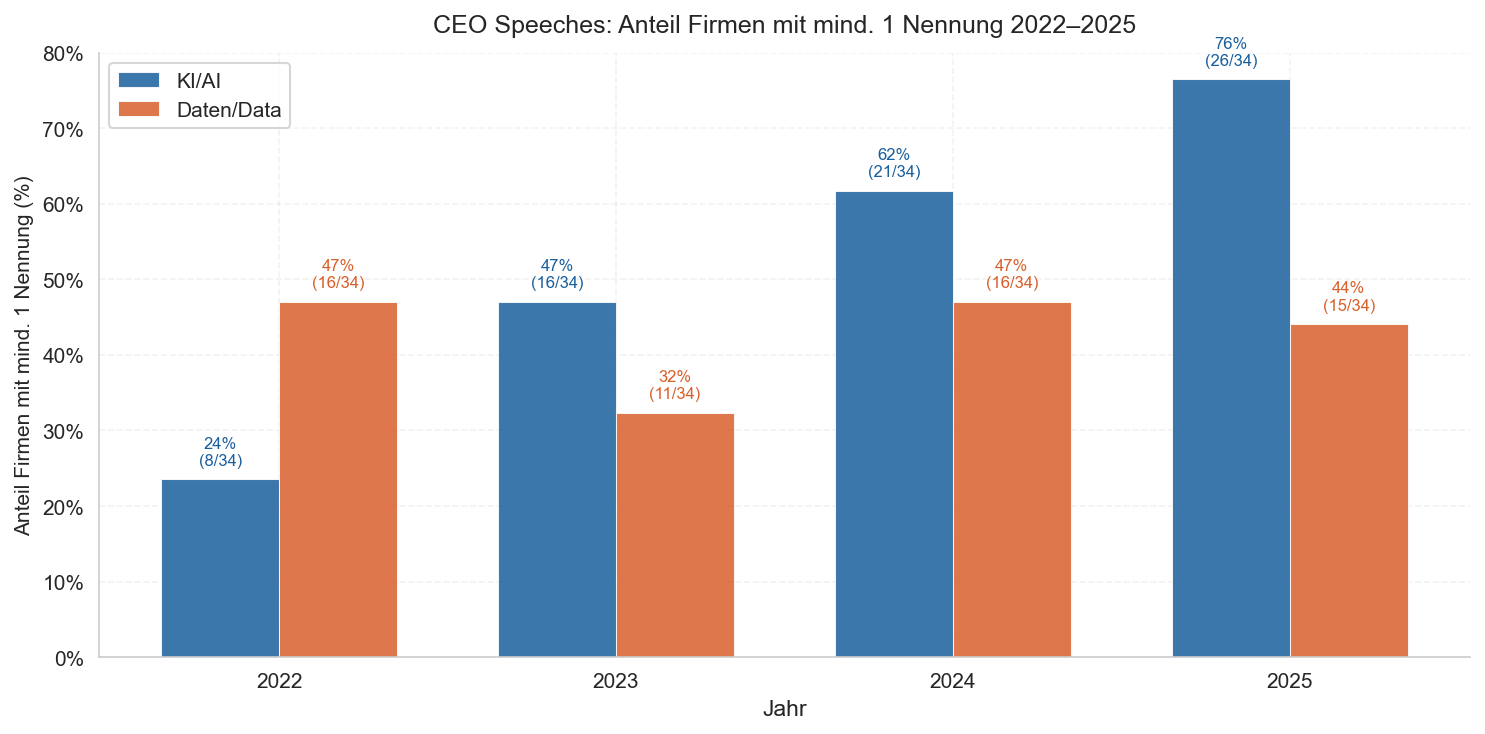

In [265]:
# ── PENETRATION CEO ONLY: Balkendiagramm ─────────────────────────────────────
pen_ceo = pen[pen['role'] == 'ceo'].copy()

x     = np.arange(len(YEARS))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))

for i, group in enumerate(GROUPS):
    sub  = pen_ceo[pen_ceo['group'] == group].sort_values('year')
    vals = [sub[sub['year'] == y]['pct'].values[0]
            if y in sub['year'].values else 0 for y in YEARS]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=group, color=C[group], alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    for bar, v, yr in zip(bars, vals, YEARS):
        sub_yr = sub[sub['year'] == yr]
        if not sub_yr.empty and v > 0:
            n_hit   = int(sub_yr['cos_with_hit'].values[0])
            n_total = int(sub_yr['total_cos'].values[0])
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + 1.5, f'{v:.0f}%\n({n_hit}/{n_total})',
                    ha='center', va='bottom', fontsize=8, color=C[group])

ax.set_xticks(x)
ax.set_xticklabels(YEARS)
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Anteil Firmen mit mind. 1 Nennung (%)', fontsize=10)
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.set_title('CEO Speeches: Anteil Firmen mit mind. 1 Nennung 2022–2025',
             fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_penetration_ceo_only_no_ar.png', bbox_inches='tight')
plt.show()

## PLOT 4 — Top-3 & Null-Nennungen pro Jahr & Gruppe

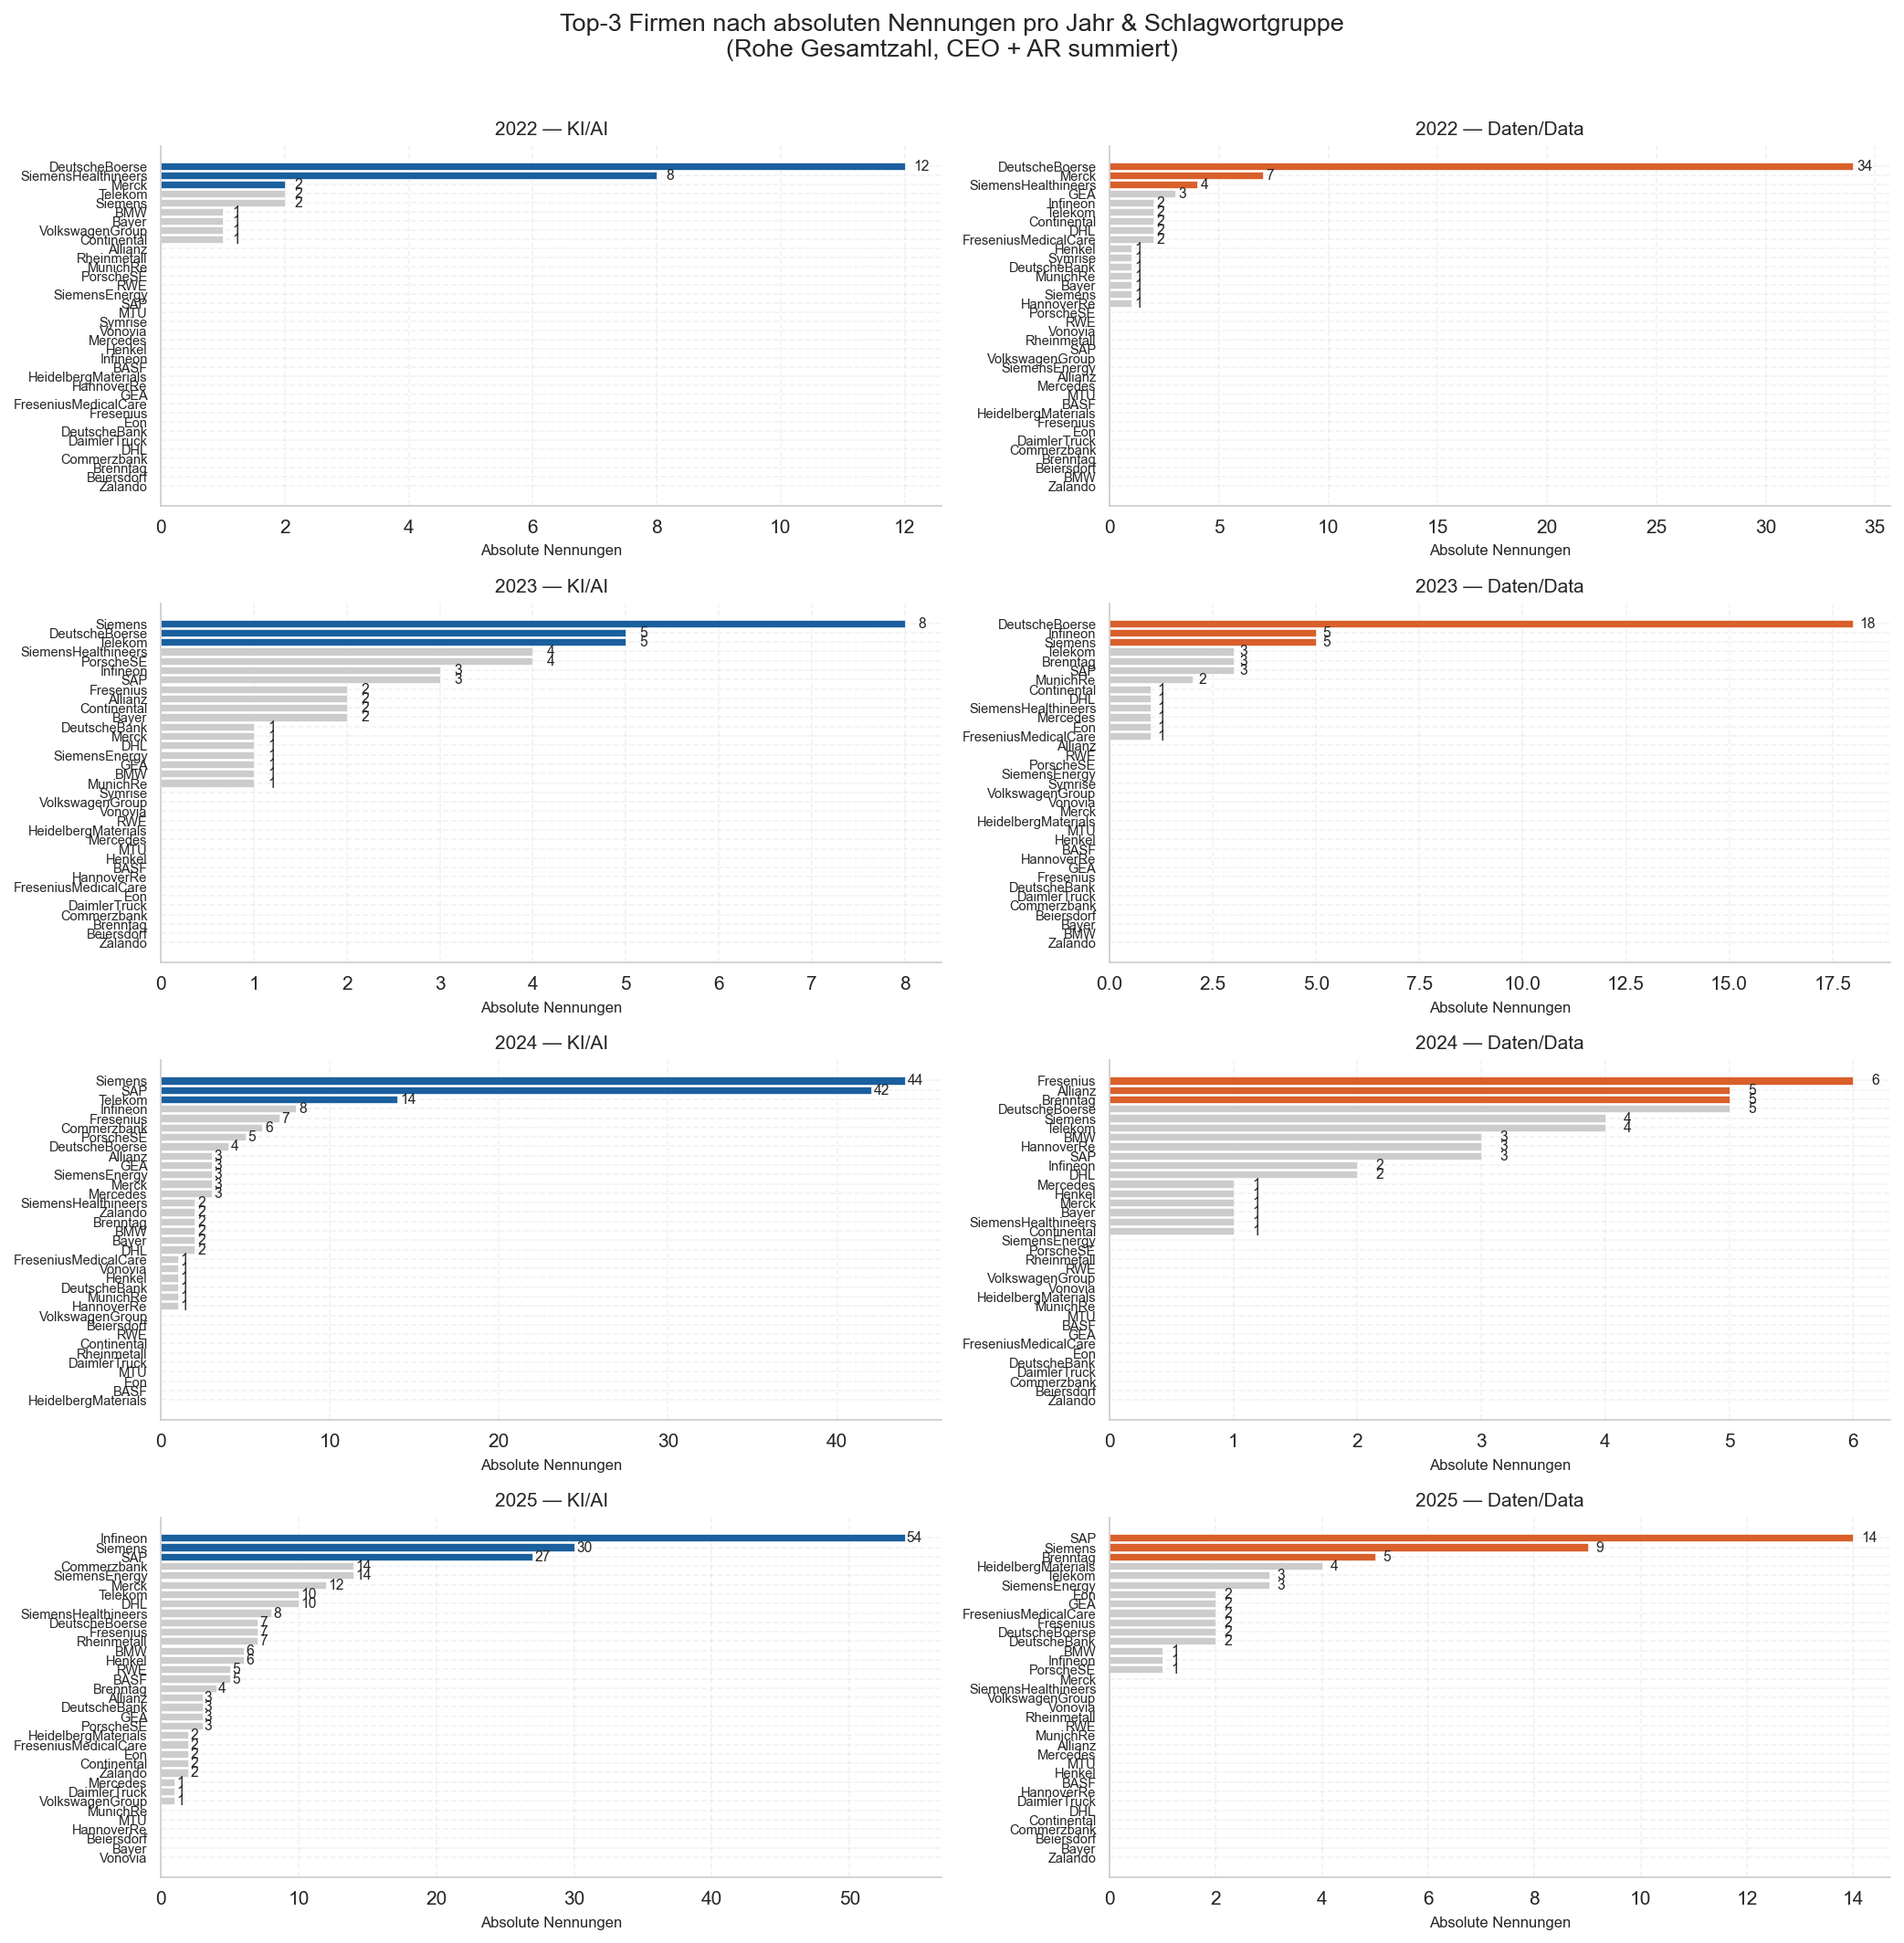

In [247]:
# ── TOP-3 & NULL-NENNUNGEN: ABSOLUT (nicht normiert) ─────────────────────────
fig, axes = plt.subplots(len(YEARS), 2,
                          figsize=(14, len(YEARS) * 3.5), sharey=False)
fig.suptitle('Top-3 Firmen nach absoluten Nennungen pro Jahr & Schlagwortgruppe\n'
             '(Rohe Gesamtzahl, CEO + AR summiert)',
             fontsize=13, y=1.01)

for row_i, year in enumerate(YEARS):
    for col_i, group in enumerate(GROUPS):
        ax  = axes[row_i][col_i]
        sub = agg[(agg['year'] == year) & (agg['group'] == group)]\
              .sort_values('count_raw', ascending=False).reset_index(drop=True)

        colors_bar = [C[group] if i < 3 else '#CCCCCC' for i in range(len(sub))]
        bars = ax.barh(sub['company'], sub['count_raw'],
                       color=colors_bar, edgecolor='white', linewidth=0.3)

        for bar, v in zip(bars, sub['count_raw']):
            if v > 0:
                ax.text(v + 0.15, bar.get_y() + bar.get_height() / 2,
                        str(int(v)), va='center', fontsize=7.5)

        ax.set_title(f'{year} — {group}', fontsize=10)
        ax.set_xlabel('Absolute Nennungen', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_top3_absolut.png', bbox_inches='tight')
plt.show()

In [248]:
# Textausgabe & Export
summary = pd.DataFrame(summary_rows)
summary.to_csv(REP_DIR / 'top3_zero_summary.csv', index=False, encoding='utf-8-sig')

In [249]:
for year in YEARS:
    print(f'\n{"═"*60}')
    print(f'  {year}')
    print(f'{"═"*60}')
    for group in GROUPS:
        s    = summary[(summary['year'] == year) & (summary['group'] == group)]
        top  = s[s['rank'] == 'Top']
        zero = s[s['rank'] == 'Null']
        print(f'\n  {group}')
        print('  Top-3:')
        for _, r in top.iterrows():
            print(f'    {r["company"]:25}  {r["count_norm"]:.2f}/1000  '
                  f'({int(r["count_raw"])} Nennungen)')
        zero_list = ', '.join(zero['company'].tolist()) if not zero.empty else '–'
        print(f'  Keine Nennung: {zero_list}')


════════════════════════════════════════════════════════════
  2022
════════════════════════════════════════════════════════════

  KI/AI
  Top-3:
    DeutscheBoerse             1.45/1000  (12 Nennungen)
    SiemensHealthineers        1.26/1000  (8 Nennungen)
    Merck                      0.55/1000  (2 Nennungen)
  Keine Nennung: Allianz, Rheinmetall, MunichRe, PorscheSE, RWE, SiemensEnergy, SAP, MTU, Symrise, Vonovia, Mercedes, Henkel, Infineon, BASF, HeidelbergMaterials, HannoverRe, GEA, FreseniusMedicalCare, Fresenius, Eon, DeutscheBank, DaimlerTruck, DHL, Commerzbank, Brenntag, Beiersdorf, Zalando

  Daten/Data
  Top-3:
    DeutscheBoerse             4.48/1000  (34 Nennungen)
    Merck                      1.94/1000  (7 Nennungen)
    Symrise                    0.88/1000  (1 Nennungen)
  Keine Nennung: PorscheSE, RWE, Vonovia, Rheinmetall, SAP, VolkswagenGroup, SiemensEnergy, Allianz, Mercedes, MTU, BASF, HeidelbergMaterials, Fresenius, Eon, DaimlerTruck, Commerzbank, Brenntag, B

## Plot 5 - Verteilung Nennungshäufigkeit

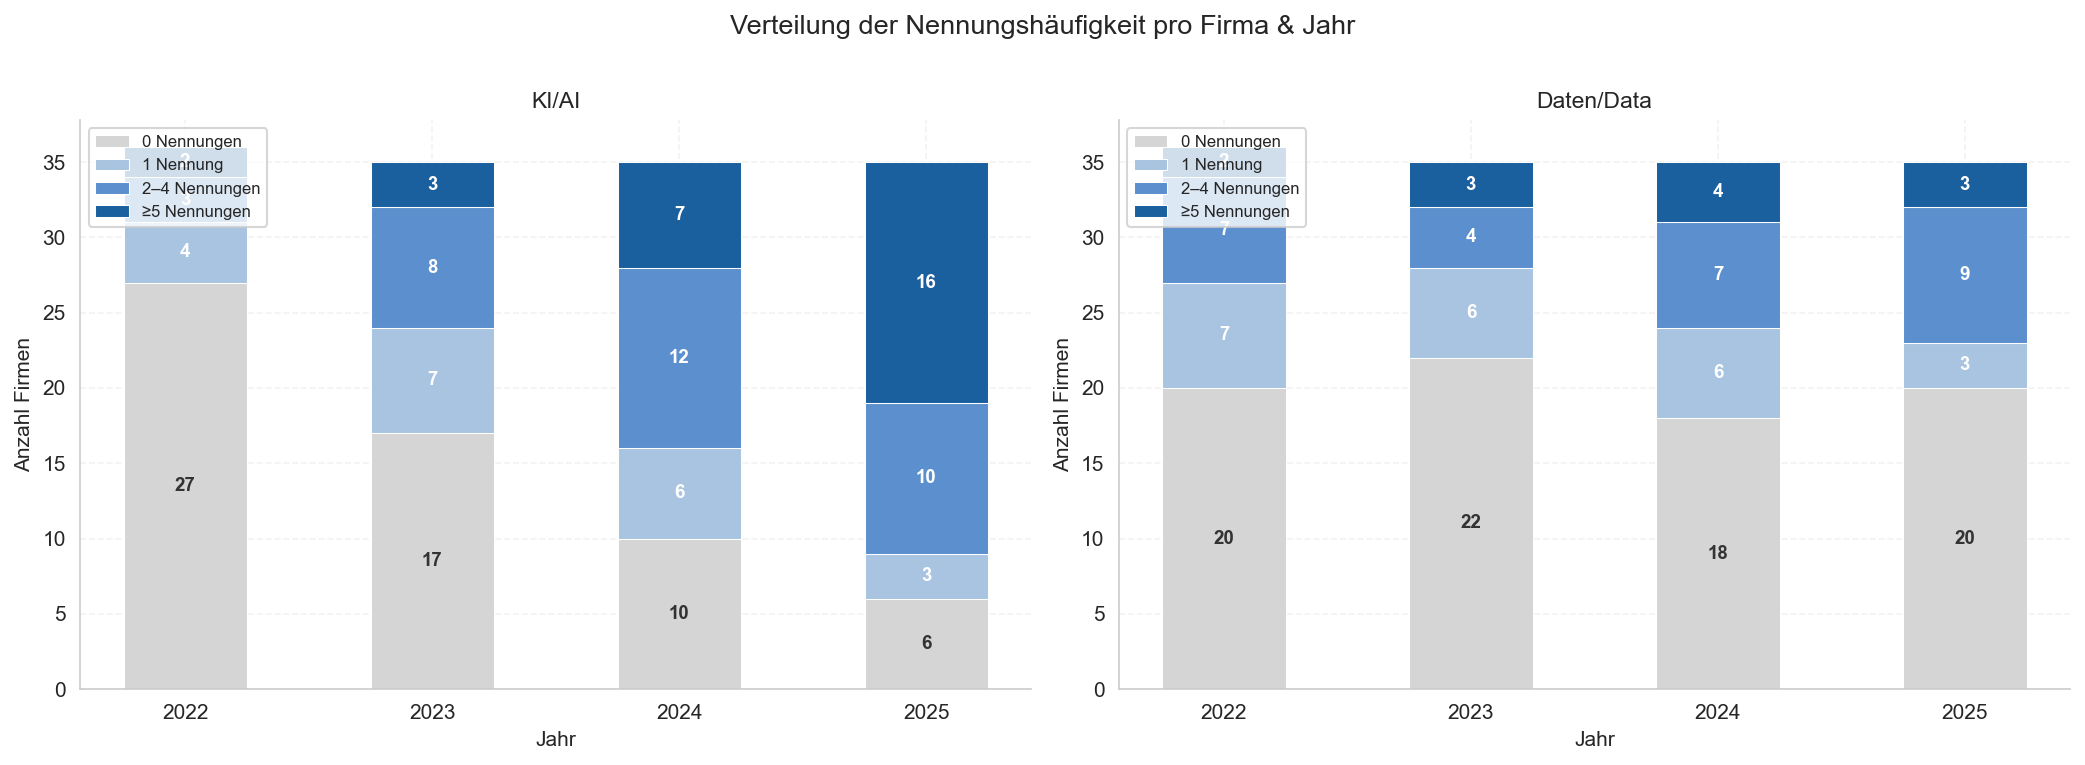

In [250]:
# ── CLUSTER-ANALYSE: Verteilung der Nennungshäufigkeit ───────────────────────
cluster_rows = []
for group in GROUPS:
    sub = agg[agg['group'] == group].copy()
    sub['cluster'] = pd.cut(
        sub['count_raw'],
        bins=[-1, 0, 1, 4, float('inf')],
        labels=['0 Nennungen', '1 Nennung', '2–4 Nennungen', '≥5 Nennungen']
    )
    counts = sub.groupby(['year', 'cluster'], observed=True).size().reset_index(name='n_companies')
    counts['group'] = group
    cluster_rows.append(counts)

cluster_df = pd.concat(cluster_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Verteilung der Nennungshäufigkeit pro Firma & Jahr', fontsize=13, y=1.01)

cluster_colors = {
    '0 Nennungen':   '#D5D5D5',
    '1 Nennung':     '#A8C4E0',
    '2–4 Nennungen': '#5B8FCE',
    '≥5 Nennungen':  '#1A5F9E',
}

for ax, group in zip(axes, GROUPS):
    sub = cluster_df[cluster_df['group'] == group]
    pivot = sub.pivot_table(index='year', columns='cluster', values='n_companies', fill_value=0)
    pivot = pivot.reindex(columns=['0 Nennungen', '1 Nennung', '2–4 Nennungen', '≥5 Nennungen'])

    bottom = np.zeros(len(pivot))
    for col in pivot.columns:
        vals = pivot[col].values
        bars = ax.bar(pivot.index, vals, bottom=bottom,
                      label=col, color=cluster_colors[col],
                      edgecolor='white', linewidth=0.5, width=0.5)
        for rect, v, b in zip(bars, vals, bottom):
            if v > 0:
                ax.text(rect.get_x() + rect.get_width() / 2,
                        b + v / 2, str(int(v)),
                        ha='center', va='center', fontsize=9,
                        color='#333' if col == '0 Nennungen' else 'white',
                        fontweight='bold')
        bottom += vals

    ax.set_title(group, fontsize=11)
    ax.set_xlabel('Jahr', fontsize=10)
    ax.set_ylabel('Anzahl Firmen', fontsize=10)
    ax.set_xticks(YEARS)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_cluster_verteilung.png', bbox_inches='tight')
plt.show()

## Plot 6 - Summe Nennungen pro Firma

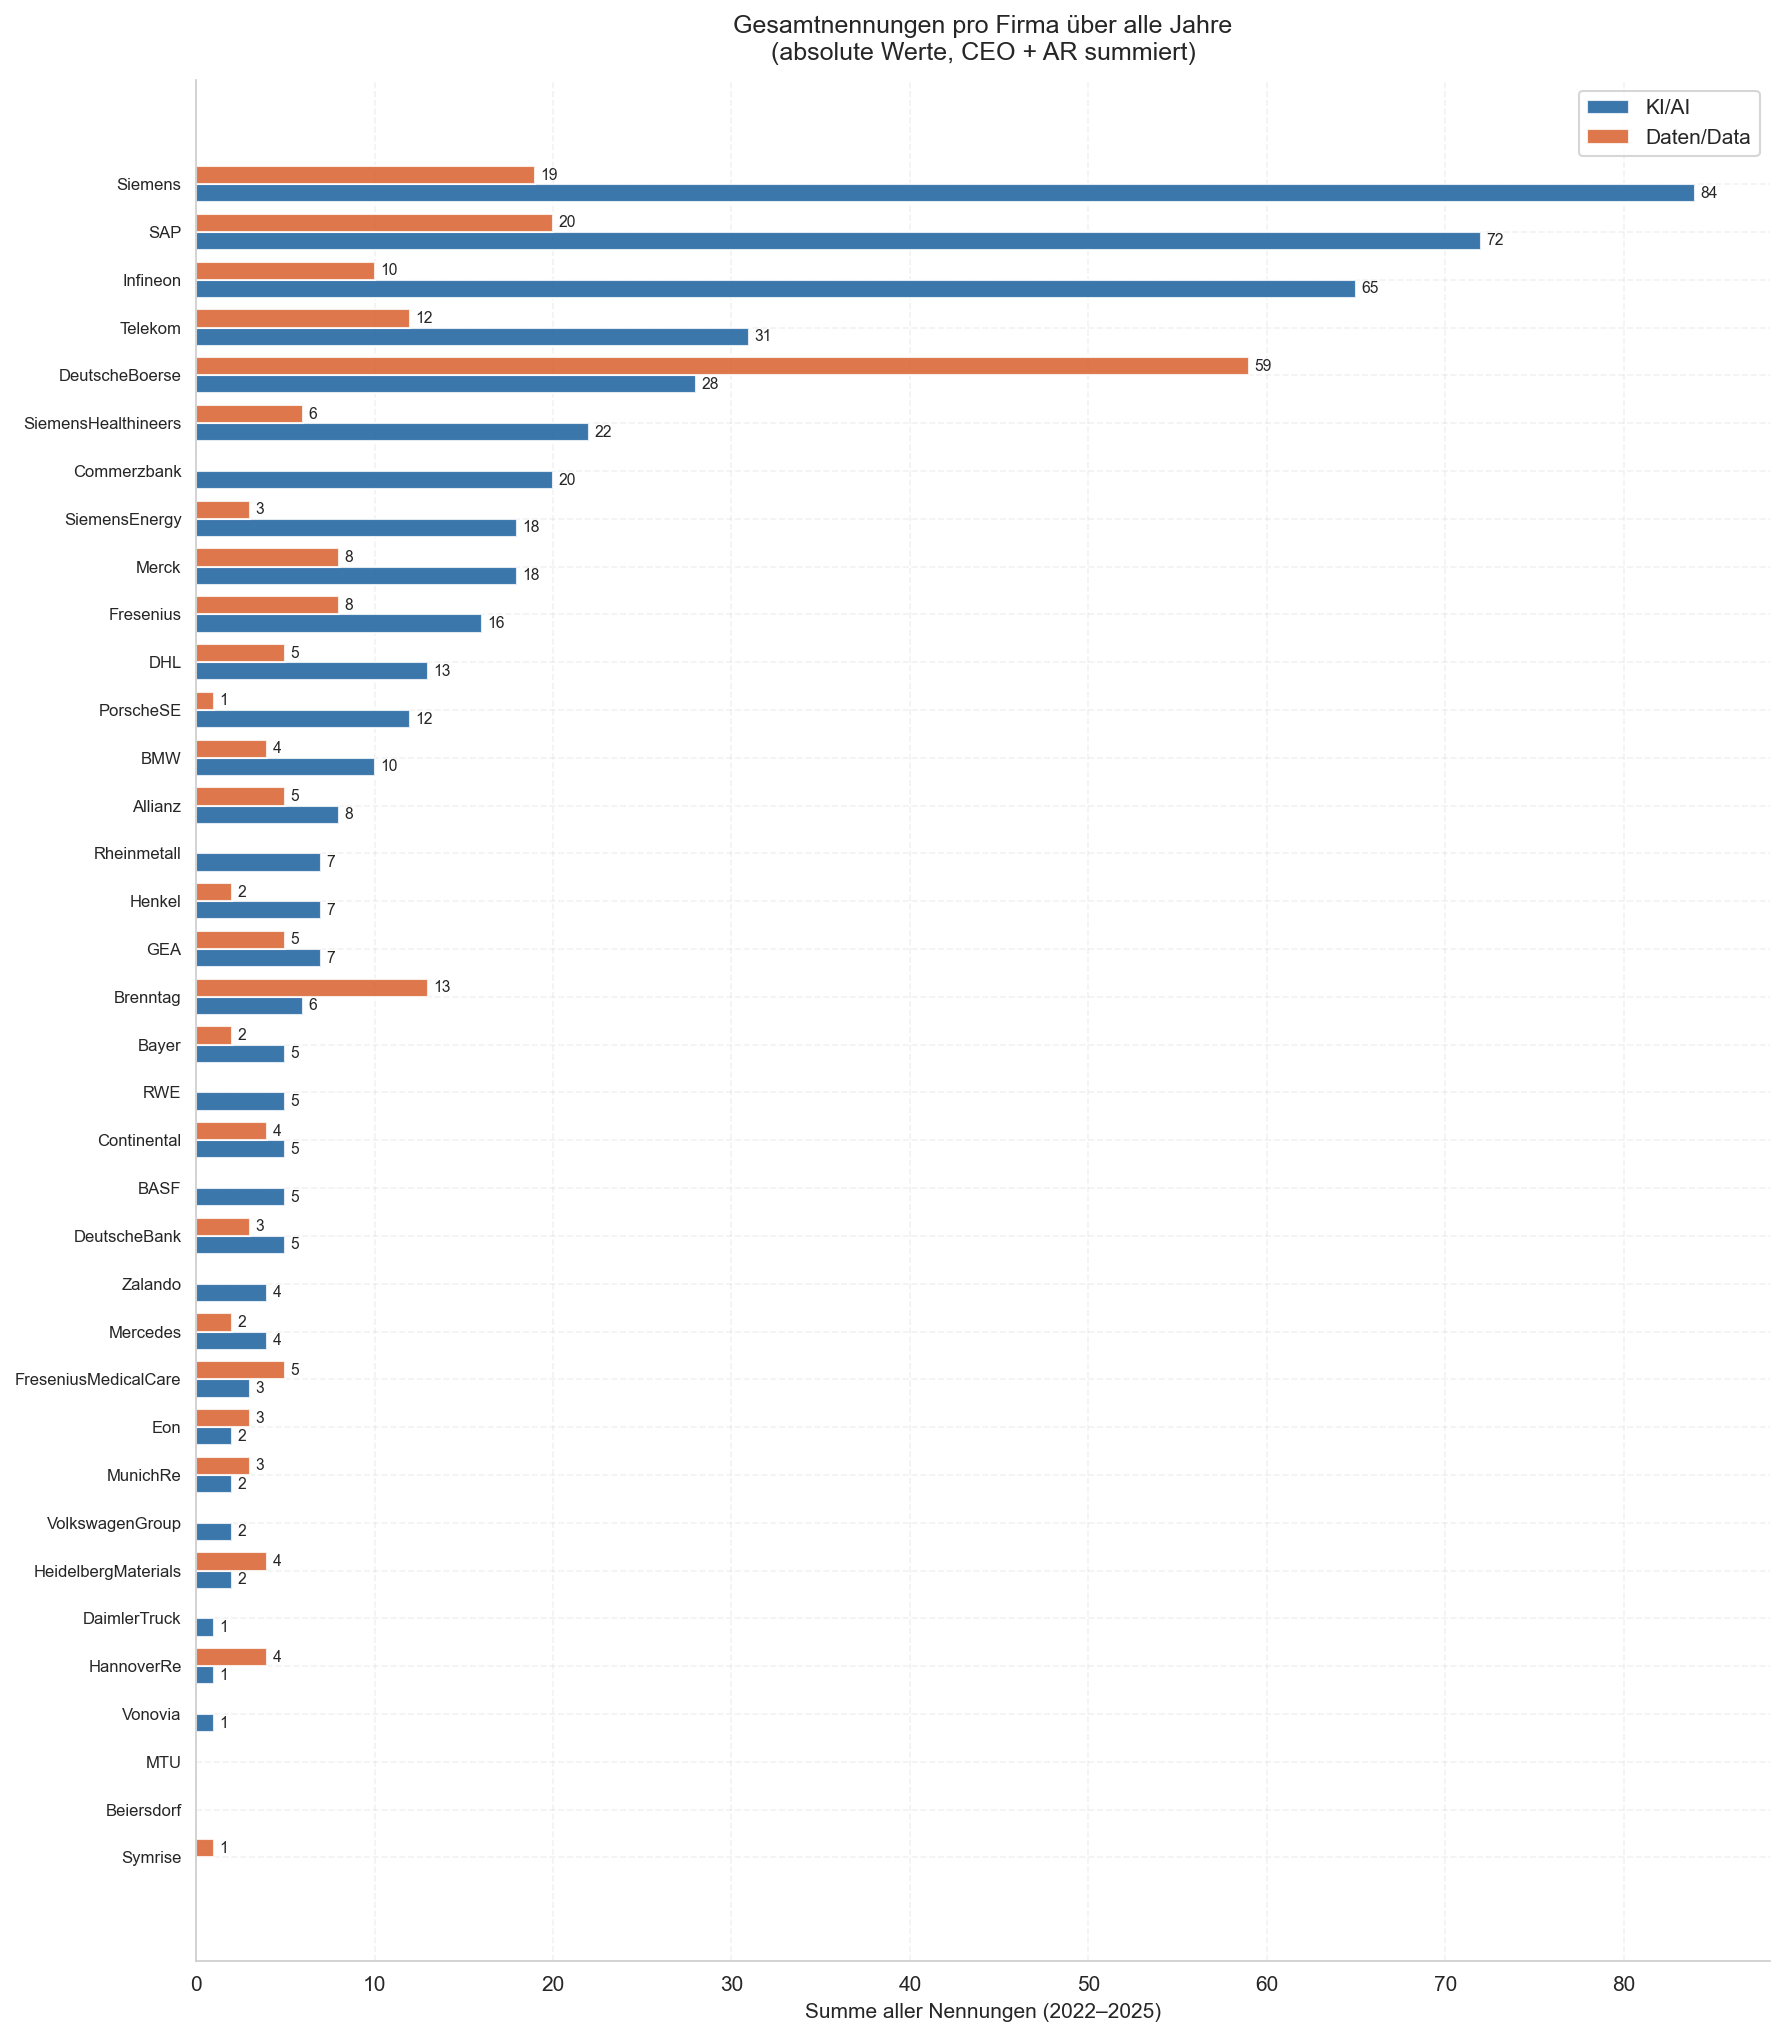


Gesamtnennungen pro Firma (sortiert nach KI/AI):
group                 Daten/Data  KI/AI
company                                
Siemens                     19.0   84.0
SAP                         20.0   72.0
Infineon                    10.0   65.0
Telekom                     12.0   31.0
DeutscheBoerse              59.0   28.0
SiemensHealthineers          6.0   22.0
Commerzbank                  0.0   20.0
Merck                        8.0   18.0
SiemensEnergy                3.0   18.0
Fresenius                    8.0   16.0
DHL                          5.0   13.0
PorscheSE                    1.0   12.0
BMW                          4.0   10.0
Allianz                      5.0    8.0
GEA                          5.0    7.0
Rheinmetall                  0.0    7.0
Henkel                       2.0    7.0
Brenntag                    13.0    6.0
RWE                          0.0    5.0
Continental                  4.0    5.0
BASF                         0.0    5.0
DeutscheBank                 3

In [251]:
# ── GESAMT-NENNUNGEN PRO FIRMA (2022–2025 summiert) ──────────────────────────
total_per_firm = agg.groupby(['company', 'group'])['count_raw'].sum().reset_index()
pivot_firms = total_per_firm.pivot_table(
    index='company', columns='group', values='count_raw', fill_value=0
).sort_values('KI/AI', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot_firms) * 0.38)))

x     = np.arange(len(pivot_firms))
width = 0.38

bars1 = ax.barh(x - width/2, pivot_firms['KI/AI'],    width, label='KI/AI',
                color=C['KI/AI'],      alpha=0.85, edgecolor='white')
bars2 = ax.barh(x + width/2, pivot_firms['Daten/Data'], width, label='Daten/Data',
                color=C['Daten/Data'], alpha=0.85, edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        w = bar.get_width()
        if w > 0:
            ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                    str(int(w)), va='center', fontsize=7.5)

ax.set_yticks(x)
ax.set_yticklabels(pivot_firms.index, fontsize=8)
ax.set_xlabel('Summe aller Nennungen (2022–2025)', fontsize=10)
ax.set_title('Gesamtnennungen pro Firma über alle Jahre\n(absolute Werte, CEO + AR summiert)',
             fontsize=12, pad=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_gesamtnennungen_pro_firma.png', bbox_inches='tight')
plt.show()

# Tabelle ausgeben
print('\nGesamtnennungen pro Firma (sortiert nach KI/AI):')
print(pivot_firms.sort_values('KI/AI', ascending=False).to_string())

## Plot 7 CEO: Von KI-Erwähnern → wie viele erwähnen auch Daten?

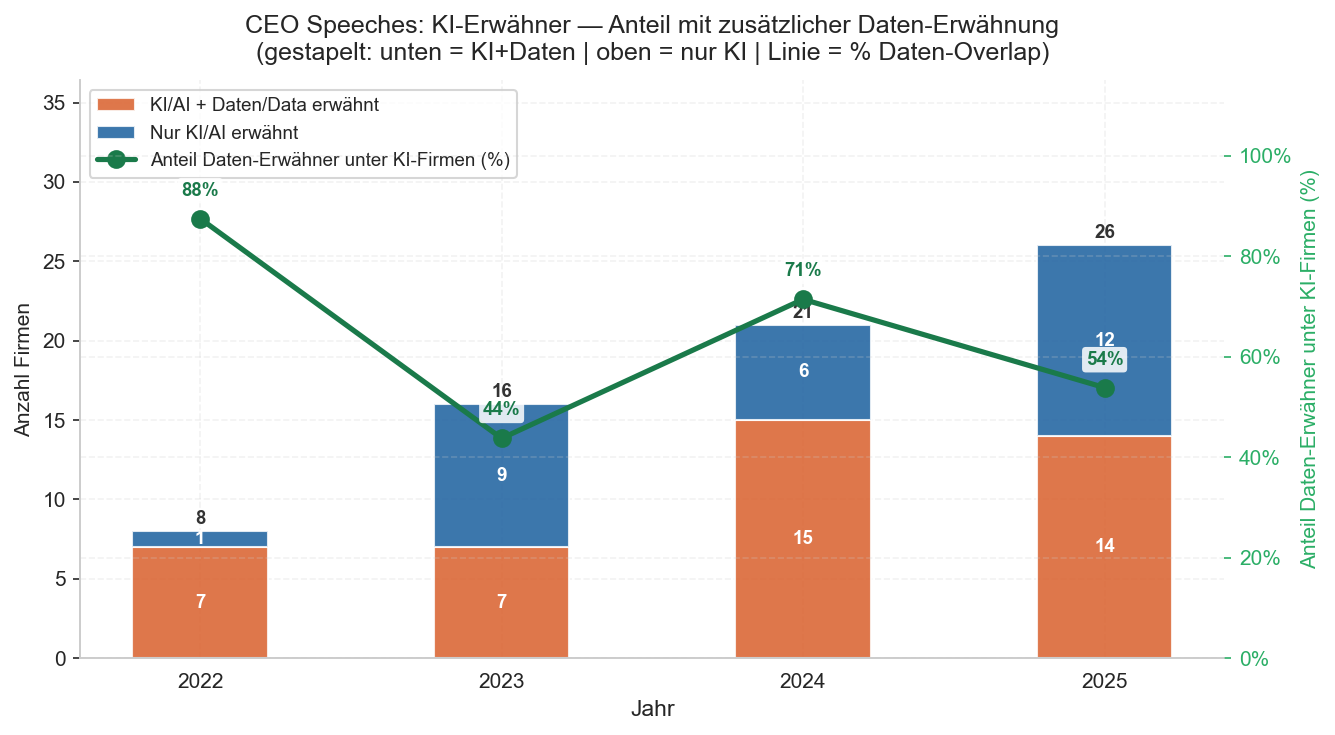

In [254]:
# ── CEO: KI-Erwähner gestapelt (Daten+KI unten, nur KI oben) ─────────────────
rows = []
for year in YEARS:
    ceo        = freq[(freq['year'] == year) & (freq['role'] == 'ceo')]
    ki_firms   = set(ceo[(ceo['group'] == 'KI/AI')     & (ceo['count_raw'] > 0)]['company'])
    data_firms = set(ceo[(ceo['group'] == 'Daten/Data') & (ceo['count_raw'] > 0)]['company'])
    both_firms = ki_firms & data_firms
    ki_only    = ki_firms - data_firms
    rows.append({
        'year':      year,
        'n_ki':      len(ki_firms),
        'n_both':    len(both_firms),
        'n_ki_only': len(ki_only),
        'pct_both':  len(both_firms) / len(ki_firms) * 100 if ki_firms else 0,
    })

df_stack = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

x     = np.arange(len(YEARS))
width = 0.45

# Unten: KI + Daten (orange), oben: nur KI (blau)
b_bottom = ax1.bar(x, df_stack['n_both'],    width,
                   label='KI/AI + Daten/Data erwähnt',
                   color=C['Daten/Data'], alpha=0.85, edgecolor='white')
b_top    = ax1.bar(x, df_stack['n_ki_only'], width,
                   bottom=df_stack['n_both'],
                   label='Nur KI/AI erwähnt',
                   color=C['KI/AI'], alpha=0.85, edgecolor='white')

# Werte in Segmenten
for i, (_, row) in enumerate(df_stack.iterrows()):
    if row['n_both'] > 0:
        ax1.text(i, row['n_both'] / 2, str(int(row['n_both'])),
                 ha='center', va='center', fontsize=9,
                 color='white', fontweight='bold')
    if row['n_ki_only'] > 0:
        ax1.text(i, row['n_both'] + row['n_ki_only'] / 2, str(int(row['n_ki_only'])),
                 ha='center', va='center', fontsize=9,
                 color='white', fontweight='bold')
    ax1.text(i, row['n_ki'] + 0.2, str(int(row['n_ki'])),
             ha='center', va='bottom', fontsize=9,
             color='#333', fontweight='bold')

# Prozentlinie
ax2.plot(x, df_stack['pct_both'], marker='o', linewidth=2.5,
         markersize=8, color='#1a7a4a',
         label='Anteil Daten-Erwähner unter KI-Firmen (%)', zorder=5)

for i, row in df_stack.iterrows():
    pct_val = row['pct_both']
    yi      = YEARS.index(row['year'])
    # Weißes Hintergrund-Rechteck damit Label vor blauem Balken lesbar bleibt
    ax2.annotate(
        f"{pct_val:.0f}%",
        (yi, pct_val),
        xytext=(0, 11),
        textcoords='offset points',
        ha='center', fontsize=9,
        color='#1a7a4a',
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.2',
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
        ),
        zorder=6,
    )

# y2-Achse: schwarz beschriften
ax2.set_ylabel('Anteil Daten-Erwähner unter KI-Firmen (%)',
               fontsize=10, color='black')
ax2.tick_params(axis='y', colors='black')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.spines['right'].set_color('black')

ax1.set_xticks(x)
ax1.set_xticklabels(YEARS)
ax1.set_xlabel('Jahr', fontsize=11)
ax1.set_ylabel('Anzahl Firmen', fontsize=10)
ax2.set_ylabel('Anteil Daten-Erwähner unter KI-Firmen (%)',
               fontsize=10, color='#2BAE66')
ax2.set_ylim(0, 115)
ax2.tick_params(axis='y', colors='#2BAE66')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, df_stack['n_ki'].max() * 1.4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title('CEO Speeches: KI-Erwähner — Anteil mit zusätzlicher Daten-Erwähnung\n'
              '(gestapelt: unten = KI+Daten | oben = nur KI | Linie = % Daten-Overlap)',
              fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_ki_dann_daten_gestapelt.png', bbox_inches='tight')
plt.show()

## Plot 8 - Co-Occurence

In [255]:
# ── CO-OCCURRENCE: DATEN-KONTEXT ──────────────────────────────────────────────
# Wörter die innerhalb von ±10 Wörtern um "Daten" auftreten

import re
from collections import Counter

# ── A: Häufigste Nachbarwörter (Word Cloud) ──
STOPWORDS_DE = {
    'der','die','das','und','in','zu','den','des','von','mit','auf','für',
    'ist','im','an','als','auch','sich','es','ein','eine','einer','einem',
    'wir','sie','nicht','dass','aus','bei','durch','nach','bis','über',
    'sind','haben','wird','werden','wurde','wurden','hat','hatte','kann',
    'um','so','wie','aber','oder','wenn','uns','ihm','ihr','ihn','ihre',
    'dem','war','einer','einem','eines','unserem','unsere','unserer',
    'haben','dabei','bereits','sowie','noch','mehr','kann','können',
}

WINDOW = 10
neighbor_counts = Counter()

for _, doc in corpus.iterrows():
    words = doc['text'].lower().split()
    for i, w in enumerate(words):
        clean_w = re.sub(r'[^a-zäöüß]', '', w)
        if clean_w in ['daten', 'data']:
            start = max(0, i - WINDOW)
            end   = min(len(words), i + WINDOW + 1)
            for neighbor in words[start:end]:
                n_clean = re.sub(r'[^a-zäöüß\-]', '', neighbor)
                if n_clean and n_clean not in STOPWORDS_DE and len(n_clean) > 3:
                    neighbor_counts[n_clean] += 1

# Word Cloud
try:
    from wordcloud import WordCloud
    wc = WordCloud(
        width=900, height=450, background_color='white',
        colormap='Blues', max_words=80,
        font_path=None,
    ).generate_from_frequencies(dict(neighbor_counts.most_common(150)))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Häufigste Nachbarwörter von "Daten/Data" (±10 Wörter)',
                 fontsize=13, pad=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'plot_daten_wordcloud.png', bbox_inches='tight')
    plt.show()
except ImportError:
    print('WordCloud nicht installiert. Führe aus: pip install wordcloud')
    print('\nTop-30 Nachbarwörter:')
    for word, count in neighbor_counts.most_common(30):
        print(f'  {word:25} {count:>4}')

# ── B: Gezielte Satzsuche: Daten + Strategie-Begriff im selben Satz ──
DATA_STRATEGY_TERMS = [
    'strategie', 'strategy', 'verfügbarkeit', 'availability',
    'silo', 'eigentum', 'ownership', 'proprietär', 'proprietary',
    'qualität', 'quality', 'governance', 'architektur', 'architecture',
    'plattform', 'platform', 'infrastruktur', 'infrastructure',
]

hit_rows = []
for _, doc in corpus.iterrows():
    sentences = re.split(r'(?<=[.!?])\s+', doc['text'])
    for sent in sentences:
        sent_lower = sent.lower()
        has_data = bool(re.search(r'\b(daten|data)\b', sent_lower))
        if not has_data:
            continue
        for strat_term in DATA_STRATEGY_TERMS:
            if strat_term in sent_lower:
                hit_rows.append({
                    'company':   doc['company'],
                    'year':      doc['year'],
                    'role':      doc['role'],
                    'strat_term': strat_term,
                    'sentence':  sent.strip()[:300],
                })

hits_df = pd.DataFrame(hit_rows)
hits_df.to_csv(REP_DIR / 'daten_strategie_saetze.csv', index=False, encoding='utf-8-sig')
print(f'\nDaten + Strategie-Begriff im selben Satz: {len(hits_df)} Treffer')
print(f'Häufigste Kombinations-Terme:')
print(hits_df['strat_term'].value_counts().head(10).to_string())
print(f'\n✓ Alle Sätze exportiert: {REP_DIR}/daten_strategie_saetze.csv')

WordCloud nicht installiert. Führe aus: pip install wordcloud

Top-30 Nachbarwörter:
  daten                      180
  intelligenz                 27
  data                        24
  unser                       18
  kunden                      18
  daten-                      18
  nutzen                      16
  diese                       15
  digitalisierung             15
  künstliche                  15
  cloud                       14
  unseren                     12
  einen                       11
  machen                      11
  neue                        11
  software                    11
  analytik                    10
  unternehmen                  9
  produzieren                  9
  besser                       8
  drei                         8
  märkte                       8
  stehen                       8
  zentrum                      8
  unseres                      8
  rohstoff                     8
  business                     8
  jahr                  

## Plot 9 - Consistency (CEO Only)

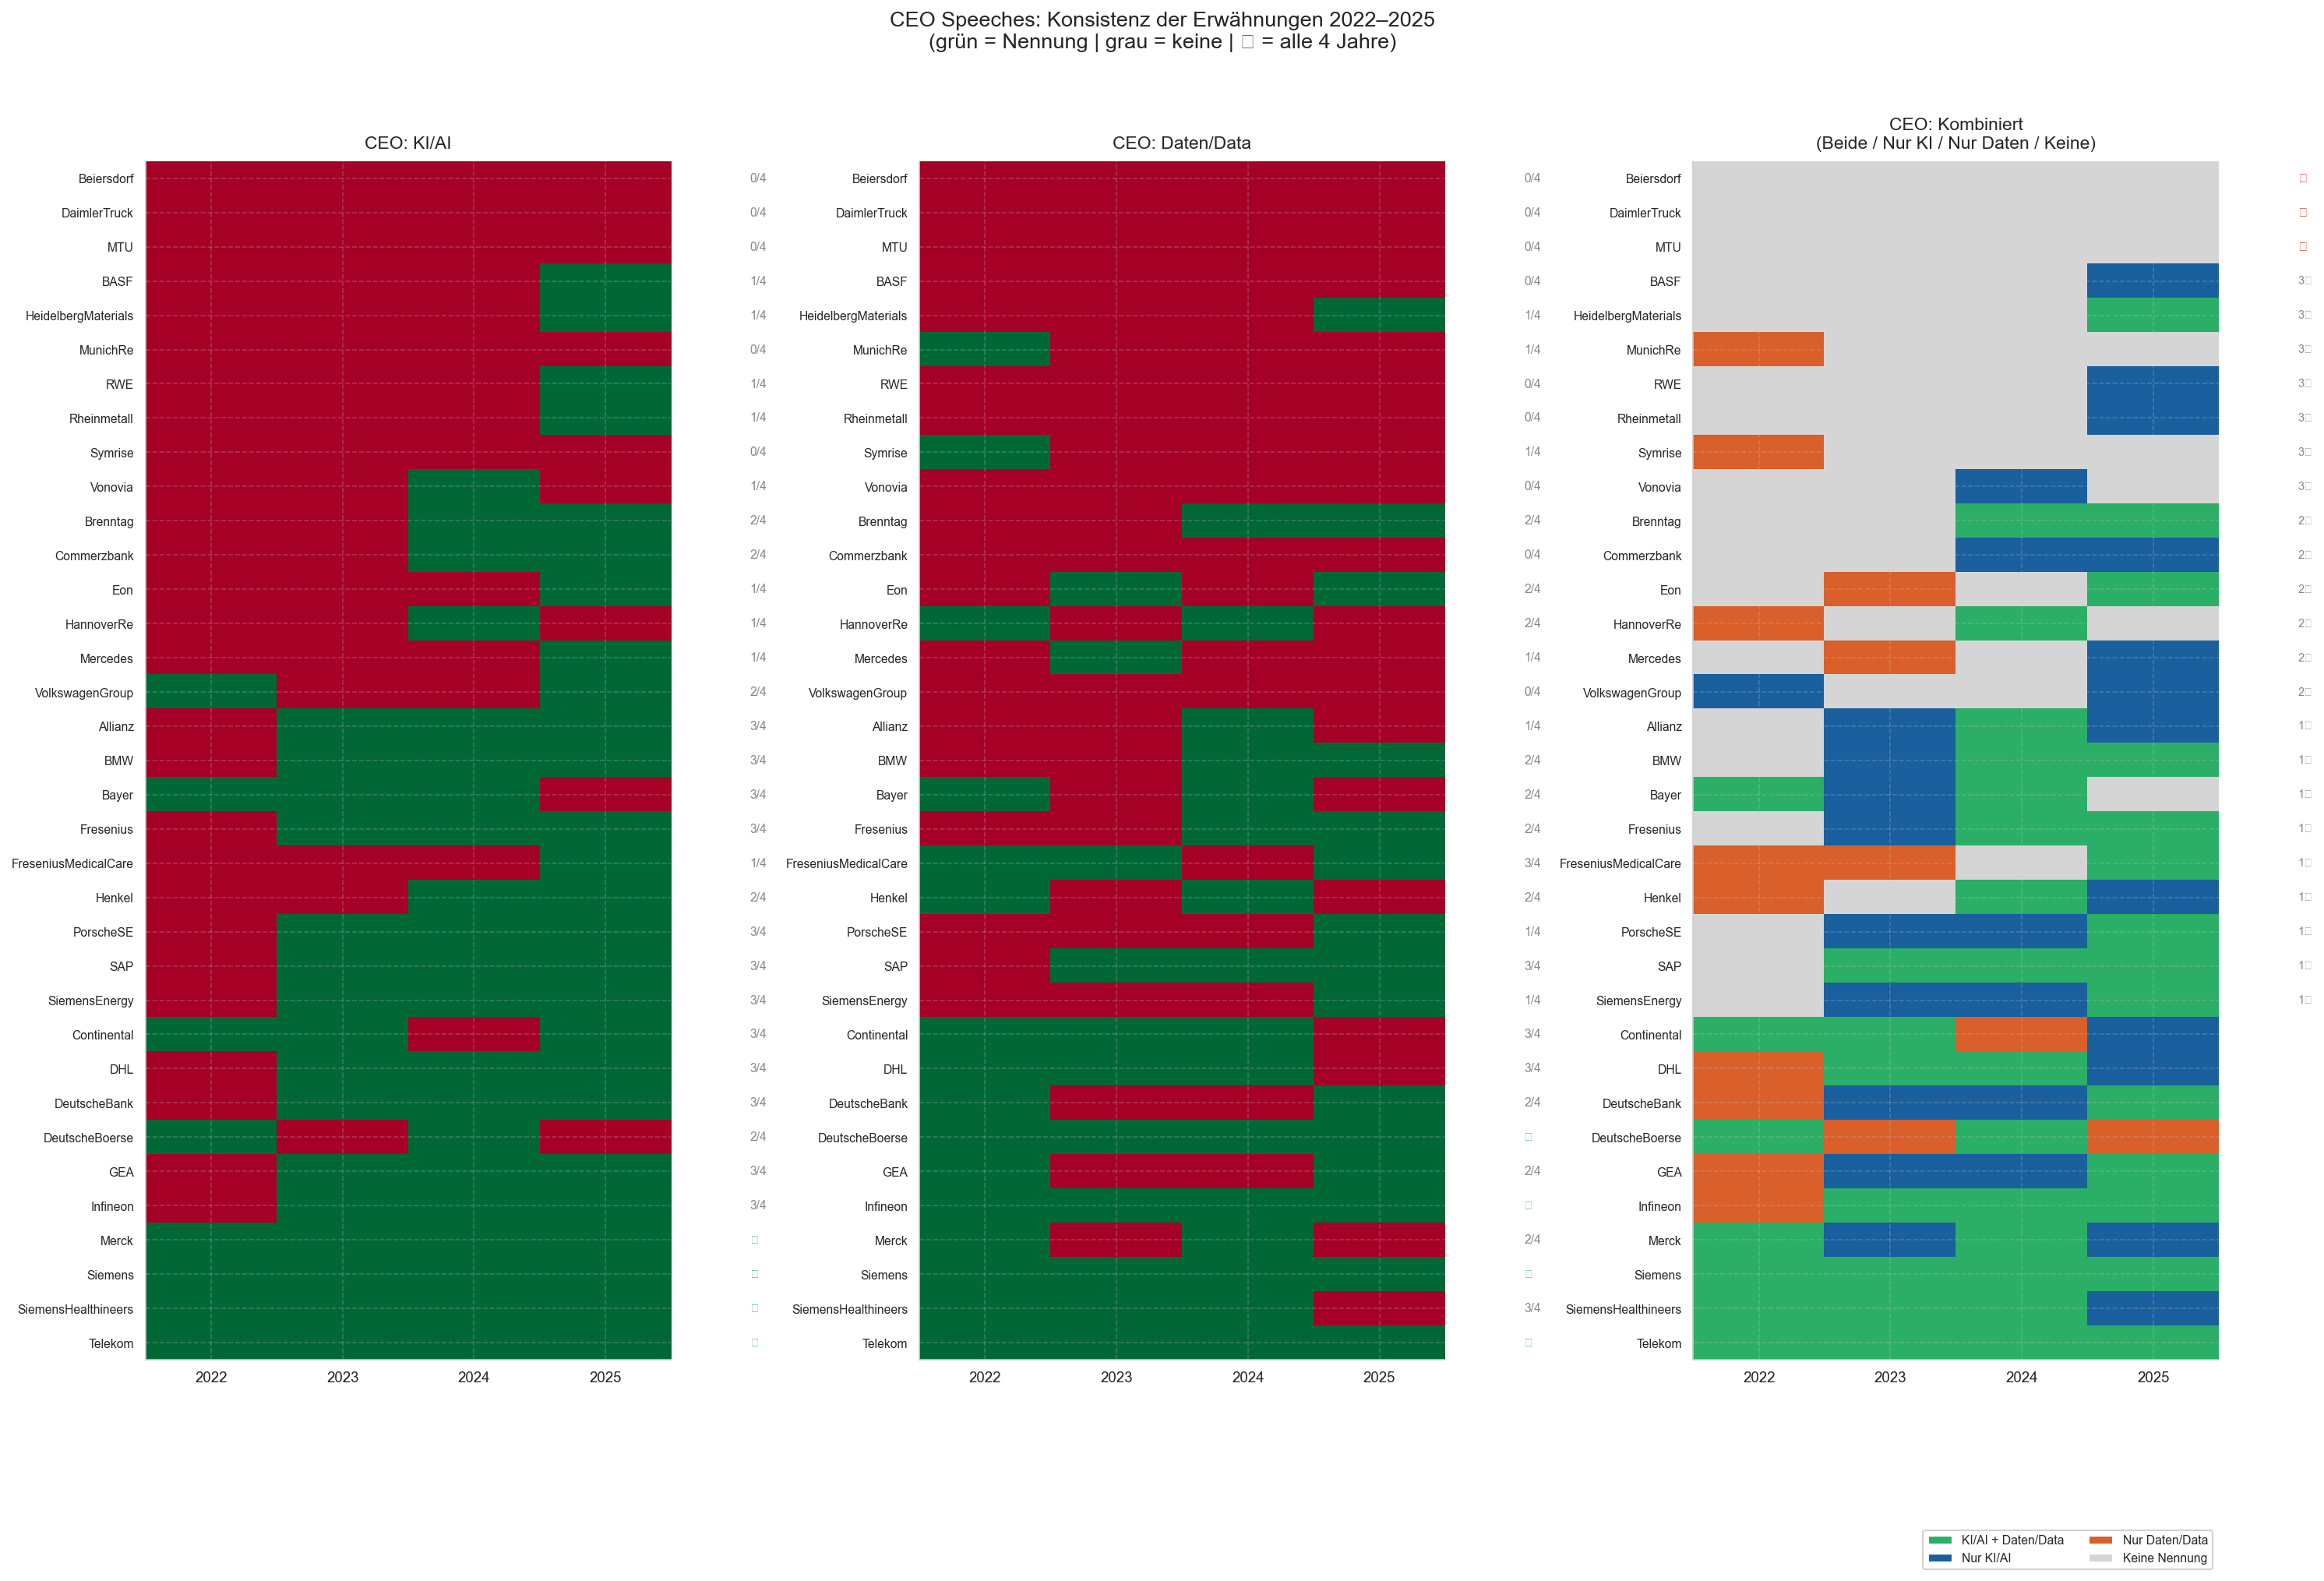

═══════════════════════════════════════════════════════
Firmen ohne jede Nennung (CEO, alle 4 Jahre):
  ✗ Beiersdorf
  ✗ DaimlerTruck
  ✗ MTU

Firmen mit KI/AI in allen 4 Jahren (CEO):
  ★ Merck
  ★ Siemens
  ★ SiemensHealthineers
  ★ Telekom

Firmen mit Daten/Data in allen 4 Jahren (CEO):
  ★ DeutscheBoerse
  ★ Infineon
  ★ Siemens
  ★ Telekom


In [256]:
# ── KONSISTENZ CEO ONLY: Einzeln + Kombiniert ────────────────────────────────

ceo_freq = freq[freq['role'] == 'ceo']

cons_rows = []
for company in ceo_freq['company'].unique():
    co = ceo_freq[ceo_freq['company'] == company]
    for group in GROUPS:
        years_hit = set(
            co[(co['group'] == group) & (co['count_raw'] > 0)]['year'].tolist()
        ) & set(YEARS)
        cons_rows.append({
            'company': company,
            'group':   group,
            'years_with_hit': sorted(years_hit),
            'n_years':        len(years_hit),
            'all_4_years':    len(years_hit) == len(YEARS),
        })

cons_df = pd.DataFrame(cons_rows)

# ── Kombiniert: keine der beiden Gruppen ──
combo_rows = []
for company in ceo_freq['company'].unique():
    co = ceo_freq[ceo_freq['company'] == company]
    years_either = set()
    years_both   = set()
    years_ki     = set()
    years_data   = set()
    for year in YEARS:
        yr = co[co['year'] == year]
        has_ki   = (yr[yr['group'] == 'KI/AI']['count_raw'].sum()     > 0)
        has_data = (yr[yr['group'] == 'Daten/Data']['count_raw'].sum() > 0)
        if has_ki or has_data:
            years_either.add(year)
        if has_ki and has_data:
            years_both.add(year)
        if has_ki:
            years_ki.add(year)
        if has_data:
            years_data.add(year)
    combo_rows.append({
        'company':          company,
        'years_either':     sorted(years_either),
        'years_both':       sorted(years_both),
        'years_ki_only':    sorted(years_ki - years_data),
        'years_data_only':  sorted(years_data - years_ki),
        'years_neither':    sorted(set(YEARS) - years_either),
        'n_neither':        len(set(YEARS) - years_either),
        'always_neither':   len(years_either) == 0,
    })

combo_df = pd.DataFrame(combo_rows)

n_companies = cons_df['company'].nunique()
fig, axes = plt.subplots(1, 3, figsize=(20, max(5, n_companies * 0.32 + 2)), sharey=False)

# Einheitliche Firmensortierung über alle drei Plots:
# sortiert nach: n_neither DESC, dann alphabetisch
sort_order = (combo_df
              .sort_values(['n_neither', 'company'], ascending=[False, True])
              ['company'].tolist())

# ── Plot A & B: Einzeln pro Gruppe ──
for ax, group in zip(axes[:2], GROUPS):
    sub = cons_df[cons_df['group'] == group].set_index('company').reindex(sort_order).reset_index()

    matrix = [[1 if y in row['years_with_hit'] else 0 for y in YEARS]
               for _, row in sub.iterrows()]
    mat = np.array(matrix)

    ax.imshow(mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels(YEARS, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['company'], fontsize=7.5)
    ax.set_title(f'CEO: {group}', fontsize=11, pad=8)

    for i, (_, row) in enumerate(sub.iterrows()):
        marker = '★' if row['all_4_years'] else f"{row['n_years']}/4"
        color  = '#2BAE66' if row['all_4_years'] else '#888'
        ax.text(len(YEARS) + 0.1, i, marker, va='center', fontsize=7.5, color=color)

# ── Plot C: Kombiniert — Kategorie pro Jahr ──
ax = axes[2]
combo_sorted = combo_df.set_index('company').reindex(sort_order).reset_index()

# 4 Kategorien pro Zelle: both=3, ki_only=2, data_only=1, neither=0
cat_matrix = []
for _, row in combo_sorted.iterrows():
    year_row = []
    for year in YEARS:
        if year in row['years_both']:
            year_row.append(3)
        elif year in row['years_ki_only']:
            year_row.append(2)
        elif year in row['years_data_only']:
            year_row.append(1)
        else:
            year_row.append(0)
    cat_matrix.append(year_row)

mat_combo = np.array(cat_matrix)

from matplotlib.colors import ListedColormap
cmap_combo = ListedColormap(['#D5D5D5', C['Daten/Data'], C['KI/AI'], '#2BAE66'])
ax.imshow(mat_combo, cmap=cmap_combo, aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=9)
ax.set_yticks(range(len(combo_sorted)))
ax.set_yticklabels(combo_sorted['company'], fontsize=7.5)
ax.set_title('CEO: Kombiniert\n(Beide / Nur KI / Nur Daten / Keine)', fontsize=11, pad=8)

# Legende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2BAE66',      label='KI/AI + Daten/Data'),
    Patch(facecolor=C['KI/AI'],     label='Nur KI/AI'),
    Patch(facecolor=C['Daten/Data'],label='Nur Daten/Data'),
    Patch(facecolor='#D5D5D5',      label='Keine Nennung'),
]
ax.legend(handles=legend_elements, fontsize=7.5,
          loc='lower right', bbox_to_anchor=(1.0, -0.18),
          ncol=2, framealpha=0.9)

# Annotation rechts: Anzahl Jahre ohne jede Nennung
for i, (_, row) in enumerate(combo_sorted.iterrows()):
    if row['always_neither']:
        ax.text(len(YEARS) + 0.1, i, '✗', va='center', fontsize=8, color='#C00')
    elif row['n_neither'] > 0:
        ax.text(len(YEARS) + 0.1, i, f"{row['n_neither']}✗",
                va='center', fontsize=7, color='#888')

fig.suptitle('CEO Speeches: Konsistenz der Erwähnungen 2022–2025\n'
             '(grün = Nennung | grau = keine | ★ = alle 4 Jahre)',
             fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_konsistenz_ceo_kombiniert_old.png', bbox_inches='tight')
plt.show()

# Textausgaben
print('═' * 55)
print('Firmen ohne jede Nennung (CEO, alle 4 Jahre):')
always_none = combo_df[combo_df['always_neither']]['company'].tolist()
for c in always_none:
    print(f'  ✗ {c}')

print(f'\nFirmen mit KI/AI in allen 4 Jahren (CEO):')
for _, row in cons_df[(cons_df['group'] == 'KI/AI') & cons_df['all_4_years']].iterrows():
    print(f'  ★ {row["company"]}')

print(f'\nFirmen mit Daten/Data in allen 4 Jahren (CEO):')
for _, row in cons_df[(cons_df['group'] == 'Daten/Data') & cons_df['all_4_years']].iterrows():
    print(f'  ★ {row["company"]}')

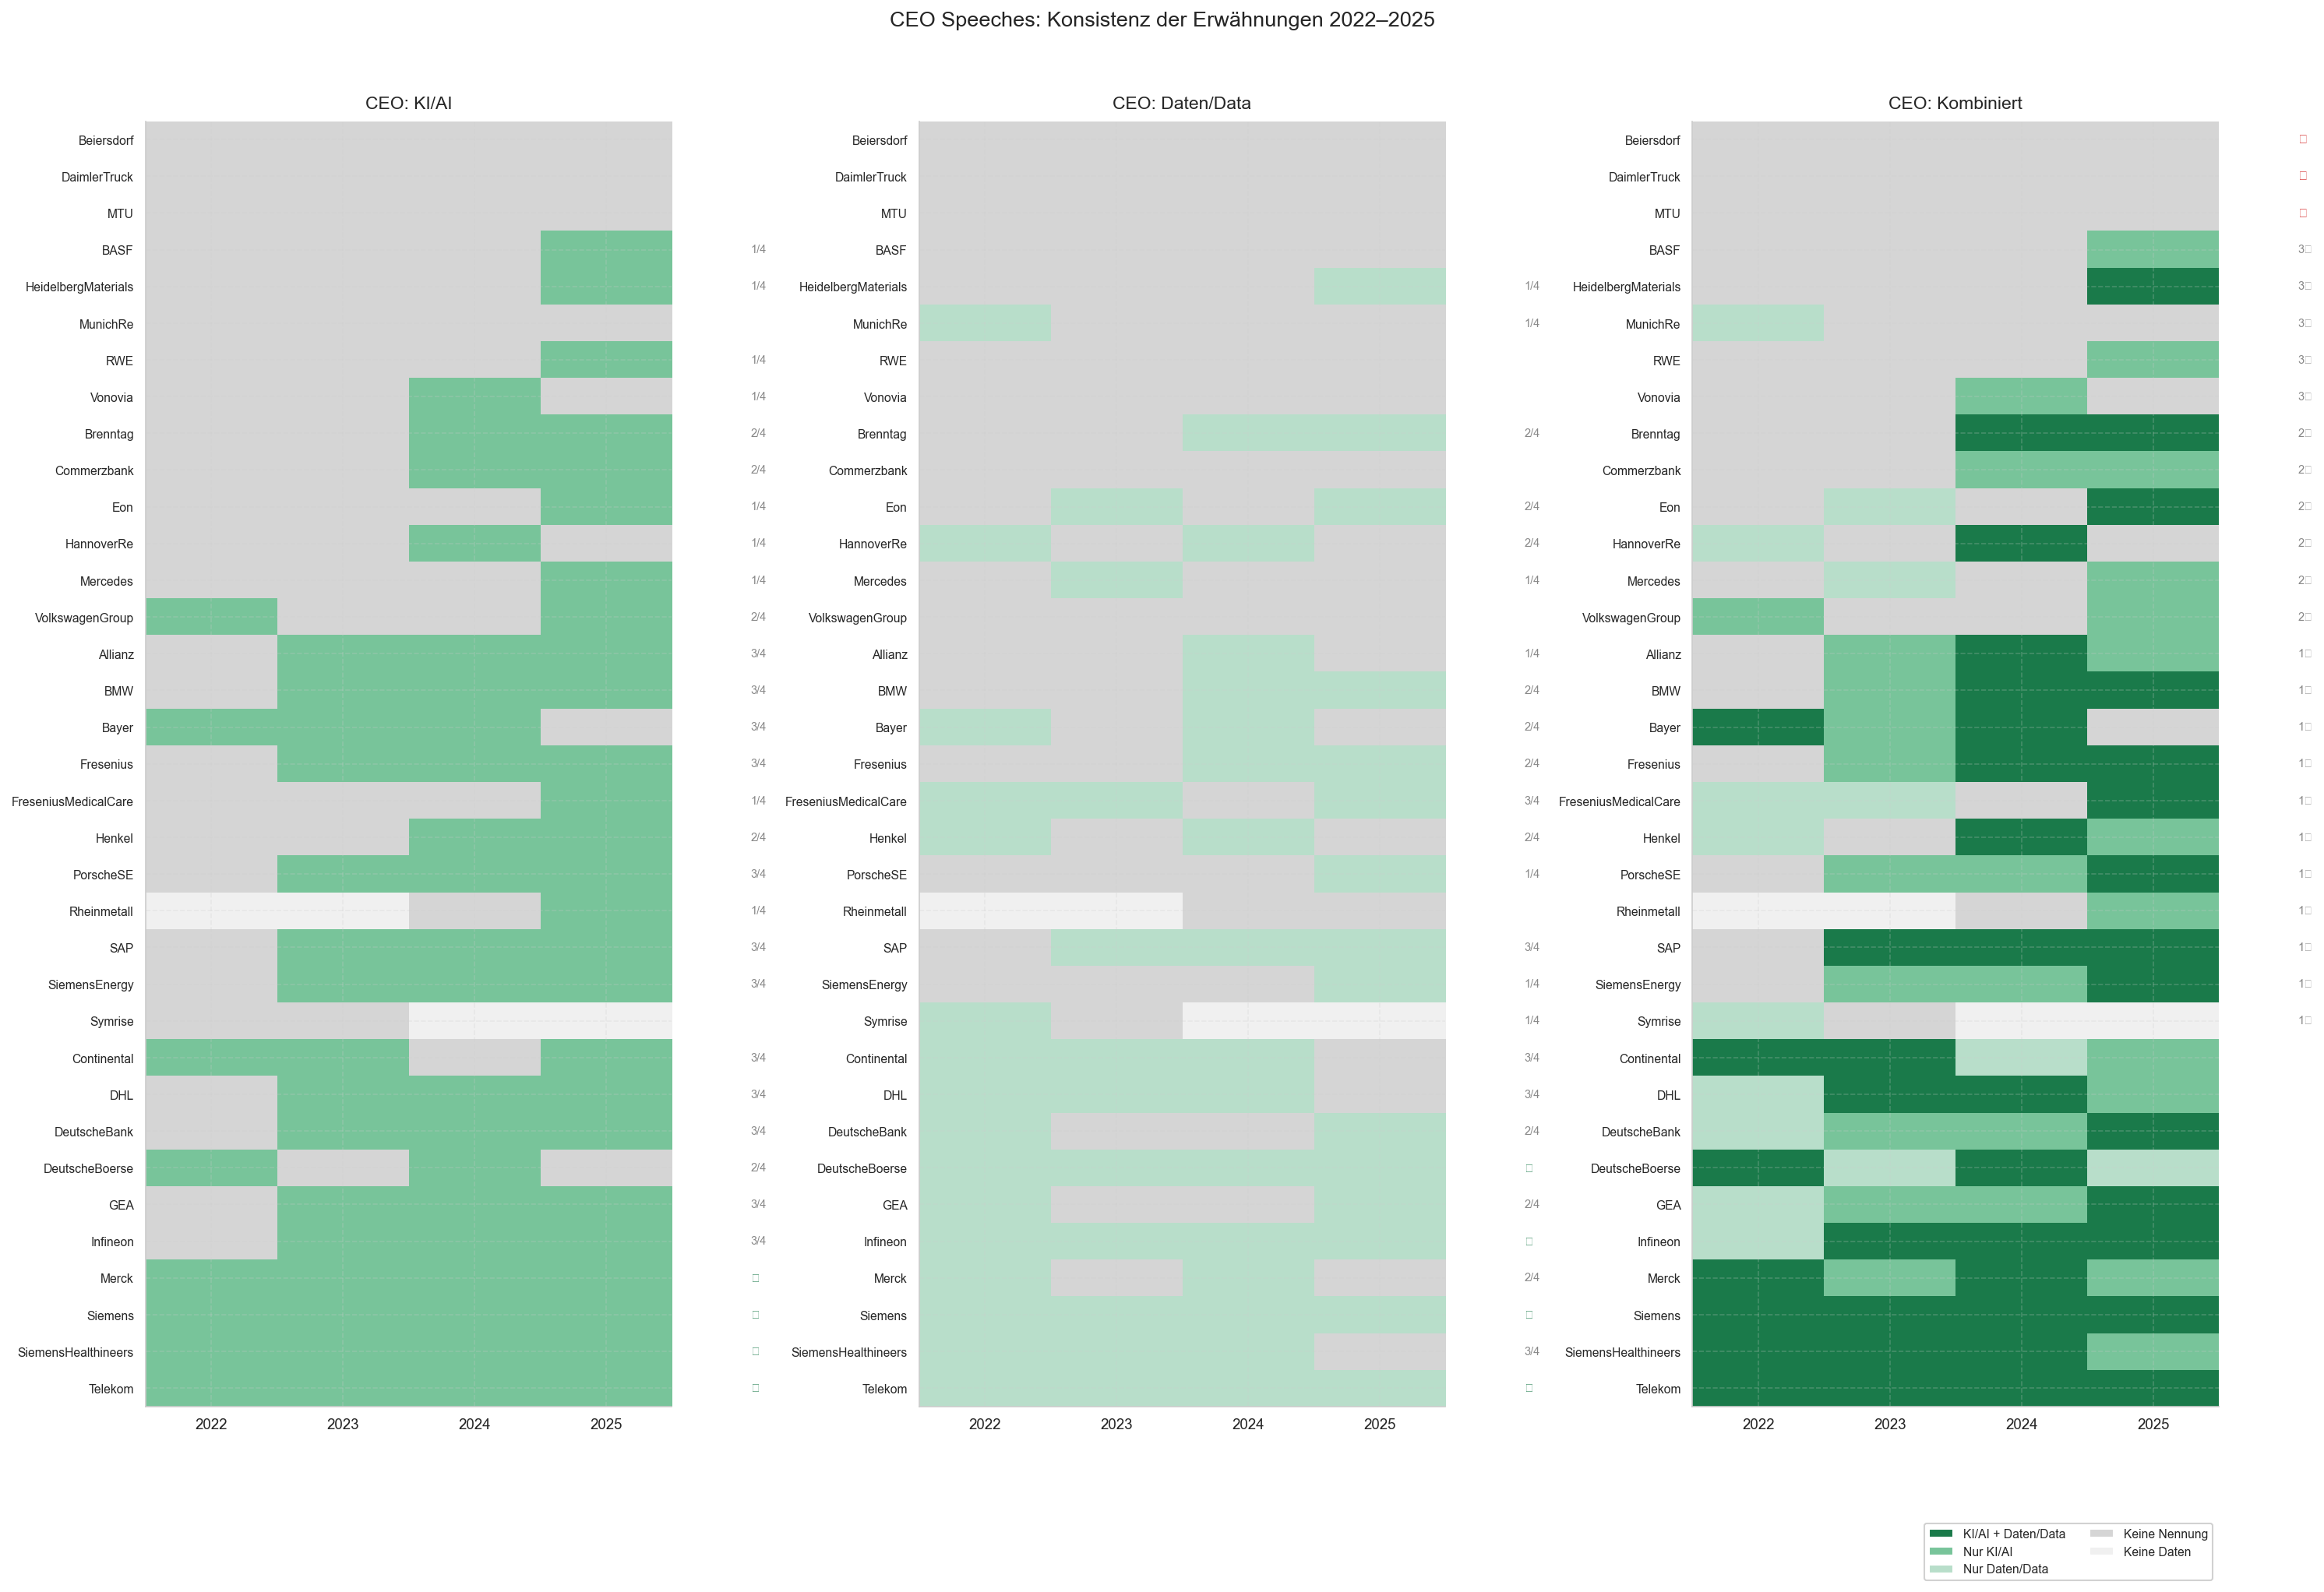

In [257]:
# ── KONSISTENZ CEO: aktualisierte Farben ─────────────────────────────────────
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Grün-Abstufungen: dunkel = beide, mittel = nur KI, hell = nur Daten
COLOR_BOTH      = '#1a7a4a'   # intensives Grün  → KI + Daten
COLOR_KI_ONLY   = '#78c49a'   # mittleres Grün   → nur KI
COLOR_DATA_ONLY = '#b8deca'   # helles Grün      → nur Daten
COLOR_NONE      = '#D5D5D5'   # grau             → keine Nennung
COLOR_NO_DATA   = '#F0F0F0'   # sehr hell        → kein Dokument

cmap_combo = ListedColormap([
    COLOR_NO_DATA,   # -1
    COLOR_NONE,      #  0
    COLOR_DATA_ONLY, #  1
    COLOR_KI_ONLY,   #  2
    COLOR_BOTH,      #  3
])
cmap_single = ListedColormap([COLOR_NO_DATA, COLOR_NONE, COLOR_KI_ONLY])
cmap_ki   = ListedColormap([COLOR_NO_DATA, COLOR_NONE, COLOR_KI_ONLY])
cmap_data = ListedColormap([COLOR_NO_DATA, COLOR_NONE, COLOR_DATA_ONLY])

# ── Voraussetzungen neu berechnen ─────────────────────────────────────────────
ceo_freq   = freq[freq['role'] == 'ceo']
ceo_exists = set(zip(ceo_freq['company'], ceo_freq['year']))

cons_rows = []
for company in ceo_freq['company'].unique():
    co = ceo_freq[ceo_freq['company'] == company]
    for group in GROUPS:
        years_hit     = set(co[(co['group'] == group) & (co['count_raw'] > 0)]['year']) & set(YEARS)
        years_with_doc = {y for y in YEARS if (company, y) in ceo_exists}
        cons_rows.append({
            'company':        company,
            'group':          group,
            'years_with_hit': sorted(years_hit),
            'years_with_doc': sorted(years_with_doc),
            'n_years':        len(years_hit),
            'all_4_years':    years_with_doc == set(YEARS) and len(years_hit) == len(YEARS),
        })
cons_df = pd.DataFrame(cons_rows)

combo_rows = []
for company in ceo_freq['company'].unique():
    co             = ceo_freq[ceo_freq['company'] == company]
    years_with_doc = {y for y in YEARS if (company, y) in ceo_exists}
    years_either, years_both, years_ki, years_data = set(), set(), set(), set()
    for year in YEARS:
        yr       = co[co['year'] == year]
        has_ki   = yr[yr['group'] == 'KI/AI']['count_raw'].sum()      > 0
        has_data = yr[yr['group'] == 'Daten/Data']['count_raw'].sum() > 0
        if has_ki or has_data:  years_either.add(year)
        if has_ki and has_data: years_both.add(year)
        if has_ki:   years_ki.add(year)
        if has_data: years_data.add(year)
    combo_rows.append({
        'company':         company,
        'years_with_doc':  years_with_doc,
        'years_either':    sorted(years_either),
        'years_both':      sorted(years_both),
        'years_ki_only':   sorted(years_ki - years_data),
        'years_data_only': sorted(years_data - years_ki),
        'years_neither':   sorted(years_with_doc - years_either),
        'n_neither':       len(years_with_doc - years_either),
        'always_neither':  len(years_with_doc) > 0 and len(years_either) == 0,
        'no_data_at_all':  len(years_with_doc) == 0,
    })
combo_df = pd.DataFrame(combo_rows)

sort_order = (combo_df
              .sort_values(['n_neither', 'company'], ascending=[False, True])
              ['company'].tolist())

n_companies = cons_df['company'].nunique()
fig, axes   = plt.subplots(1, 3, figsize=(20, max(5, n_companies * 0.32 + 2)))

# ── Plot A & B: Einzeln pro Gruppe ───────────────────────────────────────────
for ax, group, cmap in zip(axes[:2], GROUPS, [cmap_ki, cmap_data]):
    sub = (cons_df[cons_df['group'] == group]
           .set_index('company').reindex(sort_order).reset_index())

    matrix = []
    for _, row in sub.iterrows():
        year_row = []
        for year in YEARS:
            if (row['company'], year) not in ceo_exists:
                year_row.append(-1)
            elif year in row['years_with_hit']:
                year_row.append(1)
            else:
                year_row.append(0)
        matrix.append(year_row)

    ax.imshow(np.array(matrix), cmap=cmap, aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels(YEARS, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['company'], fontsize=7.5)
    ax.set_title(f'CEO: {group}', fontsize=11, pad=8)

    for i, (_, row) in enumerate(sub.iterrows()):
        if row['all_4_years']:
            ax.text(len(YEARS) + 0.1, i, '★', va='center', fontsize=7.5, color=COLOR_BOTH)
        elif row['n_years'] > 0:
            ax.text(len(YEARS) + 0.1, i, f"{row['n_years']}/4", va='center', fontsize=7, color='#888')

    legend_single = [
        Patch(facecolor=COLOR_DATA_ONLY,    label='Nennung vorhanden'),
        Patch(facecolor=COLOR_NONE,    label='Keine Nennung'),
        Patch(facecolor=COLOR_NO_DATA, label='Keine Daten'),
    ]
    #ax.legend(handles=legend_single, fontsize=7.5, loc='lower right', bbox_to_anchor=(1.0, -0.14), ncol=1, framealpha=0.9)

# ── Plot C: Kombiniert ────────────────────────────────────────────────────────
ax = axes[2]
combo_sorted = (combo_df.set_index('company').reindex(sort_order).reset_index())

cat_matrix = []
for _, row in combo_sorted.iterrows():
    year_row = []
    for year in YEARS:
        if (row['company'], year) not in ceo_exists:
            year_row.append(-1)
        elif year in row['years_both']:
            year_row.append(3)
        elif year in row['years_ki_only']:
            year_row.append(2)
        elif year in row['years_data_only']:
            year_row.append(1)
        else:
            year_row.append(0)
    cat_matrix.append(year_row)

ax.imshow(np.array(cat_matrix), cmap=cmap_combo, aspect='auto', vmin=-1, vmax=3)
ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=9)
ax.set_yticks(range(len(combo_sorted)))
ax.set_yticklabels(combo_sorted['company'], fontsize=7.5)
ax.set_title('CEO: Kombiniert', fontsize=11, pad=8)

legend_combo = [
    Patch(facecolor=COLOR_BOTH,      label='KI/AI + Daten/Data'),
    Patch(facecolor=COLOR_KI_ONLY,   label='Nur KI/AI'),
    Patch(facecolor=COLOR_DATA_ONLY, label='Nur Daten/Data'),
    Patch(facecolor=COLOR_NONE,      label='Keine Nennung'),
    Patch(facecolor=COLOR_NO_DATA,   label='Keine Daten'),
]
ax.legend(handles=legend_combo, fontsize=7.5, loc='lower right',
          bbox_to_anchor=(1.0, -0.14), ncol=2, framealpha=0.9)

for i, (_, row) in enumerate(combo_sorted.iterrows()):
    if row['no_data_at_all']:
        ax.text(len(YEARS) + 0.1, i, '–', va='center', fontsize=8, color='#BBB')
    elif row['always_neither']:
        ax.text(len(YEARS) + 0.1, i, '✗', va='center', fontsize=8, color='#C00')
    elif row['n_neither'] > 0:
        ax.text(len(YEARS) + 0.1, i, f"{row['n_neither']}✗", va='center', fontsize=7, color='#888')

fig.suptitle('CEO Speeches: Konsistenz der Erwähnungen 2022–2025',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_konsistenz_ceo_kombiniert_colors.png', bbox_inches='tight')
plt.show()

## Plot 10 - Branche (nur CEO)

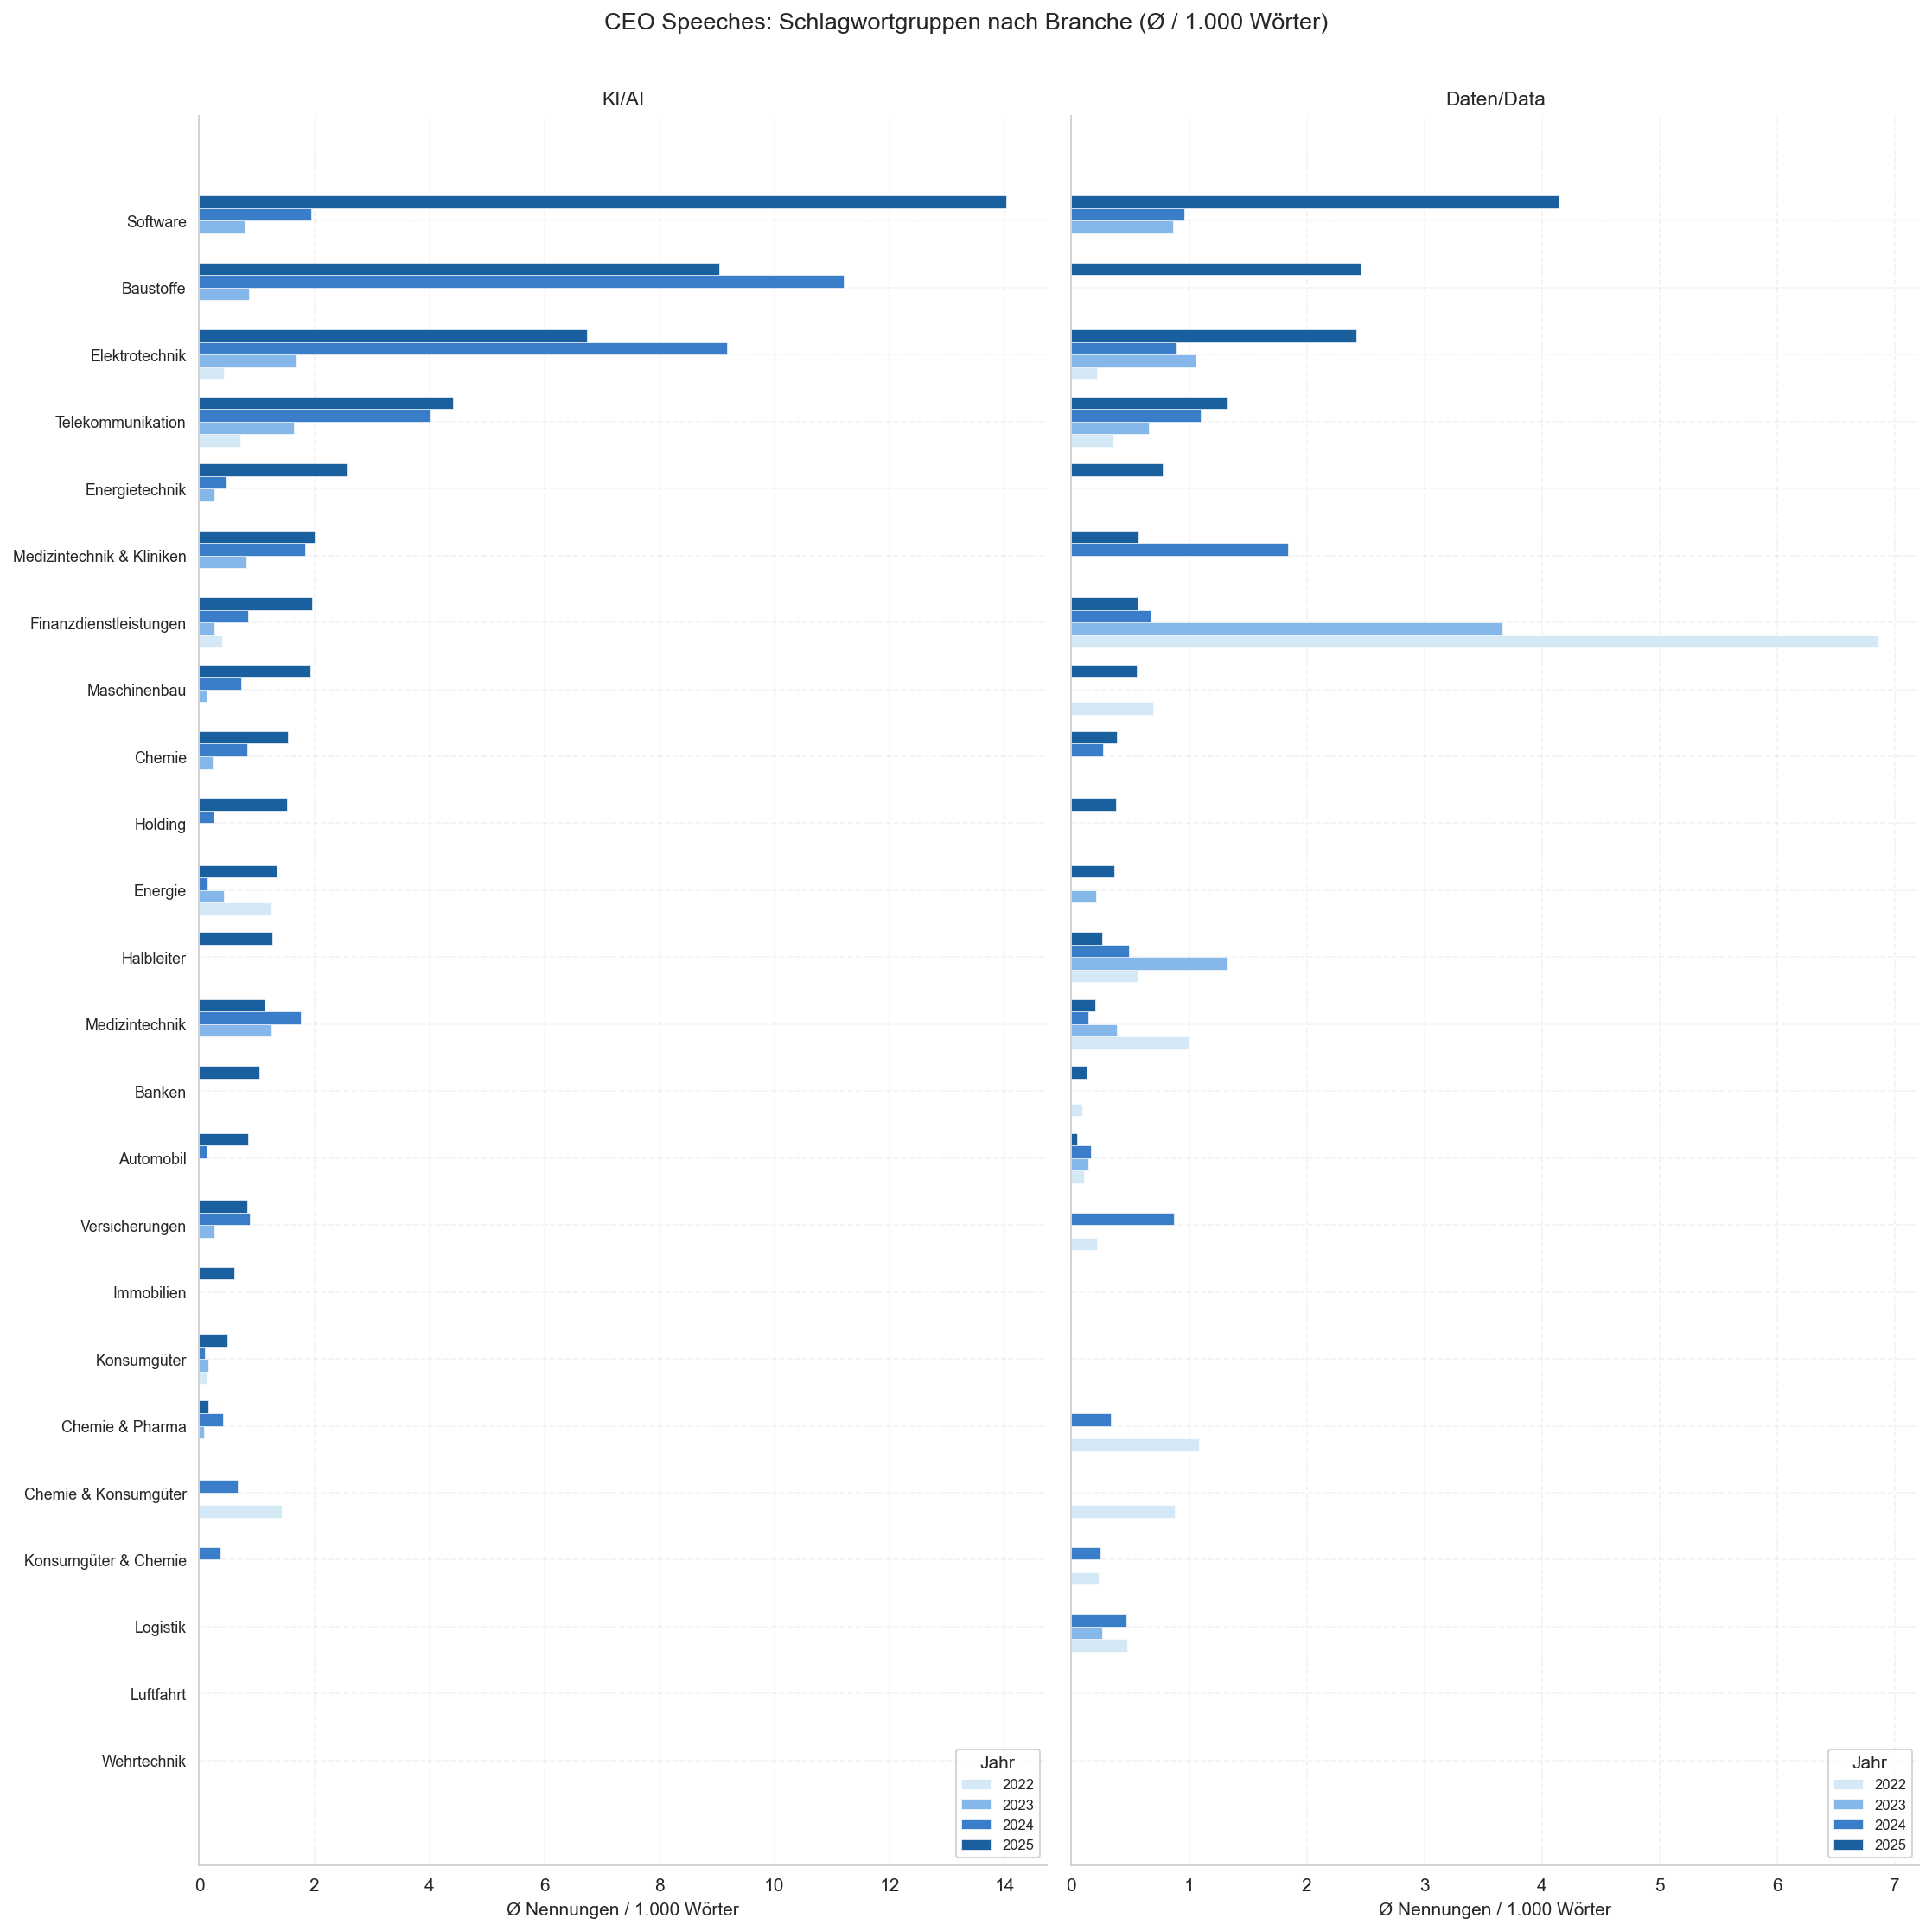

In [258]:
# ── CEO: Schlagwortgruppen nach Branche ──────────────────────────────────────

sector_df = freq[freq['role'] == 'ceo'].groupby(
    ['sector', 'year', 'group']
).agg(
    norm_mean=('count_norm', 'mean'),
    raw_sum=('count_raw',   'sum'),
).reset_index()

sectors = sorted(sector_df['sector'].unique())
n_sectors = len(sectors)

fig, axes = plt.subplots(
    1, 2, figsize=(15, max(5, n_sectors * 0.55 + 1.5)), sharey=True
)
fig.suptitle('CEO Speeches: Schlagwortgruppen nach Branche (Ø / 1.000 Wörter)',
             fontsize=13, y=1.01)

for ax, group in zip(axes, GROUPS):
    pivot = sector_df[sector_df['group'] == group].pivot_table(
        index='sector', columns='year', values='norm_mean', fill_value=0
    ).reindex(columns=YEARS, fill_value=0)
    pivot = pivot.sort_values(YEARS[-1], ascending=True)

    year_colors = ['#D5E8F5', '#85B7EB', '#3A7DC9', '#1A5F9E']
    x = np.arange(len(pivot))
    n_years = len(YEARS)
    total_w = 0.75
    w = total_w / n_years

    for i, (year, color) in enumerate(zip(YEARS, year_colors)):
        offset = (i - n_years / 2 + 0.5) * w
        vals = pivot[year].values
        bars = ax.barh(x + offset, vals, w,
                       label=str(year), color=color,
                       edgecolor='white', linewidth=0.3)

    ax.set_yticks(x)
    ax.set_yticklabels(pivot.index, fontsize=8.5)
    ax.set_xlabel('Ø Nennungen / 1.000 Wörter', fontsize=10)
    ax.set_title(group, fontsize=11)
    ax.legend(title='Jahr', fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'plot_branchen_ceo.png', bbox_inches='tight')
plt.show()

## Final

In [259]:
print('\n✓ Alle Plots gespeichert in:', FIG_DIR)
print('✓ Tabellen gespeichert in:  ', REP_DIR)


✓ Alle Plots gespeichert in: /Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis/outputs/figures/cross_company
✓ Tabellen gespeichert in:   /Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis/outputs/reports


In [260]:
# ── ÜBERSICHT: Nennungen pro Jahr, Keyword-Gruppe und Begriff ─────────────────

ceo_corpus = corpus[corpus['role'] == 'ceo']

for group, terms in TERMS.items():
    print(f'\n{"═"*60}')
    print(f'  {group}')
    print(f'{"═"*60}')
    print(f'  {"Begriff":<35}', end='')
    for year in YEARS:
        print(f'{year:>8}', end='')
    print()
    print(f'  {"─"*35}', end='')
    for _ in YEARS:
        print(f'{"─"*8}', end='')
    print()

    # Zeilensummen für jeden Term
    term_totals = {}
    for term in terms:
        row = []
        for year in YEARS:
            year_docs = ceo_corpus[ceo_corpus['year'] == year]
            total = year_docs['text'].apply(lambda t: count_term(t, term)).sum()
            row.append(total)
        term_totals[term] = row
        label = term.lstrip('~')[:33]
        print(f'  {label:<35}', end='')
        for val in row:
            marker = f'{val:>7}' if val > 0 else '      –'
            print(marker, end=' ')
        print()

    # Jahressumme je Gruppe
    print(f'  {"─"*35}', end='')
    for _ in YEARS:
        print(f'{"─"*8}', end='')
    print()
    print(f'  {"GESAMT":<35}', end='')
    for i, year in enumerate(YEARS):
        total = sum(term_totals[t][i] for t in terms)
        print(f'{total:>7} ', end='')
    print()


════════════════════════════════════════════════════════════
  KI/AI
════════════════════════════════════════════════════════════
  Begriff                                2022    2023    2024    2025
  ───────────────────────────────────────────────────────────────────
  ki                                       5       7      70     130 
  ai                                       1       3       9      17 
  artificial intelligence                  –       –       –       1 
  machine learning                         –       –       –       – 
  deep learning                            –       –       –       – 
  maschinelles Lernen                      –       –       2       2 
  maschinellem Lernen                      –       –       –       – 
  large language model                     –       –       –       1 
  llm                                      –       –       –       – 
  GenAI                                    –       –       4       – 
  künstlich\w*\s+intelligenz 

In [261]:
# ── ÜBERSICHT: Nennungen pro Jahr, Keyword-Gruppe und Begriff ─────────────────

ceo_corpus = corpus[corpus['role'] == 'ceo']

for group, terms in TERMS.items():
    print(f'\n{"═"*60}')
    print(f'  {group}')
    print(f'{"═"*60}')
    print(f'  {"Begriff":<35}', end='')
    for year in YEARS:
        print(f'{year:>8}', end='')
    print()
    print(f'  {"─"*35}', end='')
    for _ in YEARS:
        print(f'{"─"*8}', end='')
    print()

    # Zeilensummen für jeden Term
    term_totals = {}
    for term in terms:
        row = []
        for year in YEARS:
            year_docs = ceo_corpus[ceo_corpus['year'] == year]
            total = year_docs['text'].apply(lambda t: count_term(t, term)).sum()
            row.append(total)
        term_totals[term] = row
        label = term.lstrip('~')[:33]
        print(f'  {label:<35}', end='')
        for val in row:
            marker = f'{val:>7}' if val > 0 else '      –'
            print(marker, end=' ')
        print()

    # Jahressumme je Gruppe
    print(f'  {"─"*35}', end='')
    for _ in YEARS:
        print(f'{"─"*8}', end='')
    print()
    print(f'  {"GESAMT":<35}', end='')
    for i, year in enumerate(YEARS):
        total = sum(term_totals[t][i] for t in terms)
        print(f'{total:>7} ', end='')
    print()


════════════════════════════════════════════════════════════
  KI/AI
════════════════════════════════════════════════════════════
  Begriff                                2022    2023    2024    2025
  ───────────────────────────────────────────────────────────────────
  ki                                       5       7      70     130 
  ai                                       1       3       9      17 
  artificial intelligence                  –       –       –       1 
  machine learning                         –       –       –       – 
  deep learning                            –       –       –       – 
  maschinelles Lernen                      –       –       2       2 
  maschinellem Lernen                      –       –       –       – 
  large language model                     –       –       –       1 
  llm                                      –       –       –       – 
  GenAI                                    –       –       4       – 
  künstlich\w*\s+intelligenz 

In [262]:
# ── KWIC: Alle Treffer für künstlich\w*\s+intelligenz ────────────────────────

pattern = r'künstlich\w*\s+intelligenz\S*'
hits = []

for _, doc in corpus[corpus['role'] == 'ceo'].iterrows():
    for match in re.finditer(pattern, doc['text'], re.IGNORECASE):
        hits.append({
            'company': doc['company'],
            'year':    doc['year'],
            'match':   match.group(),
        })

hits_df = pd.DataFrame(hits)

if hits_df.empty:
    print('Keine Treffer.')
else:
    print(f'Treffer gesamt: {len(hits_df)}\n')
    print(f'Einzigartige Formulierungen:')
    for form, count in hits_df['match'].str.lower().value_counts().items():
        print(f'  {count:3}x  {form}')

    print(f'\nAlle Treffer nach Jahr:')
    for year in YEARS:
        sub = hits_df[hits_df['year'] == year]
        if sub.empty:
            print(f'\n  {year}: –')
            continue
        print(f'\n  {year} ({len(sub)} Treffer):')
        for _, row in sub.iterrows():
            print(f'    {row["company"]:25}  {row["match"]}')

Treffer gesamt: 160

Einzigartige Formulierungen:
   54x  künstliche intelligenz
   33x  künstlicher intelligenz
   25x  künstliche intelligenz.
   14x  künstlicher intelligenz.
   10x  künstliche intelligenz,
    4x  künstlichen intelligenz
    4x  künstliche
intelligenz.
    2x  künstliche intelligenz“
    2x  künstliche
intelligenz
    2x  künstlichen intelligenz.
    2x  künstlicher
intelligenz.
    2x  künstlicher intelligenz,
    2x  künstliche
 intelligenz.
    1x  künstliche intelligenz“.
    1x  künstlicher
intelligenz
    1x  künstliche
intelligenz,
    1x  künstlicher intelligenz:

Alle Treffer nach Jahr:

  2022 (16 Treffer):
    Bayer                      künstlicher Intelligenz
    Continental                Künstliche Intelligenz.
    DeutscheBoerse             künstliche Intelligenz.
    DeutscheBoerse             Künstlicher Intelligenz.
    Merck                      künstlicher Intelligenz.
    Merck                      Künstlicher Intelligenz
    Siemens           

In [263]:
import re
test = "Wir setzen auf AI-gestützte Prozesse und AI in der Produktion."
print(re.findall(r'\bai\b', test, re.IGNORECASE))

['AI', 'AI']


In [264]:
test = "Wir nutzen KI und KI-gestützte Systeme sowie reine KI."
print(re.findall(r'\bki\b', test, re.IGNORECASE))
# → ['KI', 'KI', 'KI']  — zählt KI in KI-gestützt mit!
print(re.findall(r'ki[\-]\w+', test, re.IGNORECASE))
# → ['KI-gestützte']

['KI', 'KI', 'KI']
['KI-gestützte']
